# Аналитика результатов олимпиады

### Содержание
1. [Загрузка и первичный осмотр данных](#1)
2. [Очистка данных](#2)
3. [Обогащение данных: производные метрики](#3)
4. [Сложность заданий](#4)
5. [Аудитория олимпиады](#5)
6. [Вовлечённость и результаты по классам](#6)
7. [Региональная аналитика и мини-отчёты](#7)
8. [Аномалии](#8)
9. [Проверка статистических гипотез](#9)
10. [Автоматические PDF-отчёты по регионам](#10)
11. [Итоговые выводы и рекомендации](#11)

In [1]:
from pathlib import Path
from textwrap import fill
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown

RAW_PATH = Path('data/olympiad_results.csv')
DICT_PATH = Path('data/olympiad_data_dictionary.csv')
CLEAN_PATH = Path('data/olympiad_results_clean.csv')
REPORT_DIR = Path('reports')
REPORT_DIR.mkdir(exist_ok=True)

N_TASKS = 12
TASKS = list(range(1, N_TASKS + 1))
ANS = [f'Task_{i}_answer' for i in TASKS]
COR = [f'Task_{i}_correct' for i in TASKS]
TIME = [f'Task_{i}_time_spent' for i in TASKS]

# Палитра: основной синий, акцентный оранжевый, нейтральный серый; для «хуже/лучше» — красный/синий
BLUE, ORANGE, AQUA, RED = '#2a78d6', '#eb6834', '#1baf7a', '#e34948'
GRAY, INK, MUTED = '#b9b8b3', '#0b0b0b', '#52514e'
SEQ_CMAP = sns.light_palette(BLUE, as_cmap=True)

plt.rcParams.update({
    'figure.dpi': 100, 'savefig.dpi': 160, 'figure.facecolor': 'white',
    'font.size': 10, 'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.titlelocation': 'center',
    'axes.edgecolor': GRAY, 'axes.labelcolor': MUTED, 'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'axes.grid.axis': 'y', 'grid.color': '#e6e5e1', 'grid.linewidth': 0.8,
    'axes.axisbelow': True, 'legend.frameon': False,
})
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.2f}'.format)

<a id="1"></a>
## 1. Загрузка и первичный осмотр данных

In [2]:
data_dict = pd.read_csv(DICT_PATH)
display(data_dict.style.set_properties(**{'text-align': 'left'})
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))

raw = pd.read_csv(RAW_PATH)
print(f'Размер таблицы: {raw.shape[0]:,} строк × {raw.shape[1]} столбцов')
raw.head()

,Столбец,Описание
0,student_id,Уникальный идентификатор ученика
1,region,Регион школы ученика (содержит опечатки и разные написания одного региона)
2,school_number,Номер школы внутри региона
3,grade,Класс ученика (5-11)
4,start_time,Время начала прохождения олимпиады
5,end_time,Время окончания прохождения олимпиады
6,Task_N_answer,Выбранный вариант ответа на задание N (1-4)
7,Task_N_correct,"Признак правильности ответа на задание N (1 - верно, 0 - неверно, NaN - пропущено)"
8,Task_N_time_spent,"Время, затраченное на задание N, в секундах"
9,total_score,"Итоговый балл за олимпиаду (в части строк тип данных - строка, а не число)"


Размер таблицы: 8,037 строк × 46 столбцов


,student_id,region,school_number,grade,start_time,end_time,Task_1_answer,Task_1_correct,Task_1_time_spent,Task_2_answer,Task_2_correct,Task_2_time_spent,Task_3_answer,Task_3_correct,Task_3_time_spent,Task_4_answer,Task_4_correct,Task_4_time_spent,Task_5_answer,Task_5_correct,Task_5_time_spent,Task_6_answer,Task_6_correct,Task_6_time_spent,Task_7_answer,Task_7_correct,Task_7_time_spent,Task_8_answer,Task_8_correct,Task_8_time_spent,Task_9_answer,Task_9_correct,Task_9_time_spent,Task_10_answer,Task_10_correct,Task_10_time_spent,Task_11_answer,Task_11_correct,Task_11_time_spent,Task_12_answer,Task_12_correct,Task_12_time_spent,total_score,device_type,attempts_count,disconnects
0,S200000,Краснодар,9,11,2026-04-10 11:10:00,2026-04-10 11:25:19,4.00,0.00,93.00,1.00,0.00,75.00,2.00,0.00,65.00,1.00,0.00,81.00,1.00,0.00,66.00,1.00,0.00,47.00,2.00,0.00,109.00,3.00,1.00,30.00,3.00,1.00,59.00,1.00,1.00,86.00,2.00,0.00,84.00,4.00,0.00,124.00,3,desktop,2,0
1,S200001,Ростов-на-Дону,44,9,2026-04-10 10:30:00,2026-04-10 10:44:19,3.00,0.00,105.00,2.00,0.00,71.00,2.00,0.00,59.00,1.00,1.00,117.00,3.00,0.00,59.00,3.00,1.00,60.00,4.00,1.00,67.00,1.00,1.00,76.00,1.00,0.00,33.00,2.00,1.00,76.00,4.00,1.00,73.00,4.00,0.00,63.00,6,mobile,2,0
2,S200002,Екатеринбург,44,9,2026-04-10 10:25:00,2026-04-10 10:38:33,4.00,1.00,60.00,3.00,0.00,98.00,2.00,0.00,67.00,1.00,1.00,26.00,3.00,0.00,86.00,3.00,1.00,81.00,4.00,1.00,84.00,2.00,1.00,71.00,1.00,0.00,62.00,NaN,NaN,NaN,1.00,1.00,101.00,1.00,1.00,77.00,7,mobile,1,1
3,S200003,Казань,44,11,2026-04-10 10:04:00,2026-04-10 10:18:18,1.00,0.00,58.00,1.00,1.00,91.00,4.00,0.00,63.00,2.00,1.00,59.00,2.00,1.00,71.00,4.00,0.00,5.00,1.00,0.00,57.00,2.00,1.00,80.00,1.00,0.00,95.00,2.00,0.00,93.00,4.00,0.00,100.00,3.00,1.00,86.00,5,mobile,1,0
4,S200004,Уфа,26,9,2026-04-10 10:53:00,2026-04-10 11:08:36,4.00,0.00,111.00,1.00,1.00,74.00,2.00,0.00,59.00,4.00,1.00,111.00,3.00,0.00,24.00,2.00,0.00,59.00,3.00,1.00,36.00,1.00,1.00,93.00,3.00,1.00,71.00,1.00,1.00,123.00,4.00,0.00,79.00,2.00,0.00,96.00,6,mobile,2,0


### 1.1 Типы столбцов

In [3]:
meta_cols = ['student_id', 'region', 'school_number', 'grade', 'start_time', 'end_time',
             'total_score', 'device_type', 'attempts_count', 'disconnects']
types = pd.DataFrame({
    'тип': raw[meta_cols].dtypes.astype(str),
    'уникальных': raw[meta_cols].nunique(),
    'пропусков': raw[meta_cols].isna().sum(),
})
display(types)
print('Типы столбцов по заданиям (Task_N_answer/correct/time_spent):', raw[ANS + COR + TIME].dtypes.value_counts().to_dict())

,тип,уникальных,пропусков
student_id,str,8000,0
region,str,19,0
school_number,int64,59,0
grade,int64,7,0
start_time,str,180,0
end_time,str,5673,0
total_score,int64,13,0
device_type,str,3,0
attempts_count,int64,2,0
disconnects,int64,5,0


Типы столбцов по заданиям (Task_N_answer/correct/time_spent): {dtype('float64'): 36}


### 1.2 Пропуски

In [4]:
na_by_task = pd.DataFrame({
    'answer': raw[ANS].isna().sum().to_numpy(),
    'correct': raw[COR].isna().sum().to_numpy(),
    'time_spent': raw[TIME].isna().sum().to_numpy(),
}, index=pd.Index(TASKS, name='Задание'))
na_by_task['доля пропусков, %'] = na_by_task['answer'] / len(raw) * 100
display(na_by_task.T)

same_pattern = (raw[ANS].isna().to_numpy() == raw[COR].isna().to_numpy()).all() and \
               (raw[ANS].isna().to_numpy() == raw[TIME].isna().to_numpy()).all()
print('Пропуски в Task_N_answer/correct/time_spent совпадают построчно:', same_pattern)
print('Пропусков в остальных столбцах:', int(raw[meta_cols].isna().sum().sum()))
print('\nЧисло пропущенных заданий на ученика:')
print(raw[ANS].isna().sum(axis=1).value_counts().sort_index().to_string())

Задание,1,2,3,4,5,6,7,8,9,10,11,12
answer,318.00,341.00,315.00,310.00,299.00,327.00,312.00,316.00,313.00,316.00,287.00,321.00
correct,318.00,341.00,315.00,310.00,299.00,327.00,312.00,316.00,313.00,316.00,287.00,321.00
time_spent,318.00,341.00,315.00,310.00,299.00,327.00,312.00,316.00,313.00,316.00,287.00,321.00
"доля пропусков, %",3.96,4.24,3.92,3.86,3.72,4.07,3.88,3.93,3.89,3.93,3.57,3.99


Пропуски в Task_N_answer/correct/time_spent совпадают построчно: True
Пропусков в остальных столбцах: 0

Число пропущенных заданий на ученика:
0    4975
1    2424
2     572
3      57
4       9


Пропуски есть только в столбцах с заданиями, причём все 3 поля пусты одновременно - это **пропущенное учеником задание**,
а не техническая потеря данных (по словарю: `NaN — пропущено`). У ~38 % учеников пропущено хотя бы одно задание, максимум - 4 из 12.

### 1.3 Дубликаты

In [5]:
n_full_dup = raw.duplicated().sum()
n_id_dup = raw['student_id'].duplicated().sum()
print(f'Полных дубликатов строк: {n_full_dup}')
print(f'Повторов student_id:     {n_id_dup}')
raw[raw['student_id'].duplicated(keep=False)].sort_values('student_id').head(6)[meta_cols]

Полных дубликатов строк: 37
Повторов student_id:     37


,student_id,region,school_number,grade,start_time,end_time,total_score,device_type,attempts_count,disconnects
234,S200234,Санкт-Петербург,35,9,2026-04-10 10:41:00,2026-04-10 10:55:19,3,mobile,1,0
235,S200234,Санкт-Петербург,35,9,2026-04-10 10:41:00,2026-04-10 10:55:19,3,mobile,1,0
641,S200640,Пермь,48,11,2026-04-10 10:37:00,2026-04-10 10:54:46,7,desktop,1,0
642,S200640,Пермь,48,11,2026-04-10 10:37:00,2026-04-10 10:54:46,7,desktop,1,0
963,S200961,Санкт-Петербург,27,7,2026-04-10 09:25:00,2026-04-10 09:40:14,5,desktop,1,0
964,S200961,Санкт-Петербург,27,7,2026-04-10 09:25:00,2026-04-10 09:40:14,5,desktop,1,0


Все повторы student_id - полные копии строк.

### 1.4 Категориальные поля

In [6]:
display(raw['region'].value_counts().rename('Участников').to_frame().T)
for col in ['device_type', 'grade', 'attempts_count', 'disconnects']:
    print(f'{col}:', raw[col].value_counts().sort_index().to_dict())
print('school_number: от', raw['school_number'].min(), 'до', raw['school_number'].max())
print('Формат student_id «S + 6 цифр»:', raw['student_id'].str.fullmatch(r'S\d{6}').all())

region,Уфа,Краснодар,Воронеж,Ростов-на-Дону,Новосибирск,Пермь,Екатеринбург,Казань,Москва,Санкт-Петербург,г.Казань,СПб,казань,мск,Санкт Петербург,москва,спб,г. Москва,Moskva
Участников,847,807,807,804,791,766,754,748,736,718,39,37,34,31,27,26,26,20,19


device_type: {'desktop': 4773, 'mobile': 2854, 'tablet': 410}
grade: {5: 1108, 6: 1178, 7: 1177, 8: 1114, 9: 1137, 10: 1170, 11: 1153}
attempts_count: {1: 4101, 2: 3936}
disconnects: {0: 6636, 1: 1267, 2: 123, 3: 10, 4: 1}
school_number: от 1 до 59
Формат student_id «S + 6 цифр»: True


В столбце `region` **19 написаний для 10 регионов**. Остальные поля без ошибок.

### 1.5 Баллы и ответы
В словаре указано, что `total_score` в части строк может быть строкой. Проверим, приводится ли столбец к числу и совпадает ли
он с суммой `Task_N_correct`.

In [7]:
score_num = pd.to_numeric(raw['total_score'], errors='coerce')
score_calc = raw[COR].fillna(0).sum(axis=1)
print('Тип total_score при чтении:', raw['total_score'].dtype)
print('Значений, не приводимых к числу:', score_num.isna().sum())
print('Расхождений total_score с суммой Task_N_correct:', (score_num != score_calc).sum())
print('Допустимые значения answer:', sorted(pd.unique(raw[ANS].stack())))
print('Допустимые значения correct:', sorted(pd.unique(raw[COR].stack())))
print('time_spent, сек: min = {:.0f}, max = {:.0f}'.format(raw[TIME].min().min(), raw[TIME].max().max()))

Тип total_score при чтении: int64
Значений, не приводимых к числу: 0
Расхождений total_score с суммой Task_N_correct: 0
Допустимые значения answer: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(nan)]
Допустимые значения correct: [np.float64(0.0), np.float64(1.0), np.float64(nan)]
time_spent, сек: min = 1, max = 191


В этой выгрузке `total_score` уже числовой и везде равен числу верных ответов.

### 1.6 Время прохождения

,значение
Дат проведения,1
end_time ≤ start_time,0
Сумма Task_N_time_spent ≠ длительности сессии,0
Аномальных сессий,73


Старты: 2026-04-10 09:00:00 - 2026-04-10 11:59:00 | Последнее окончание: 2026-04-10 12:16:44


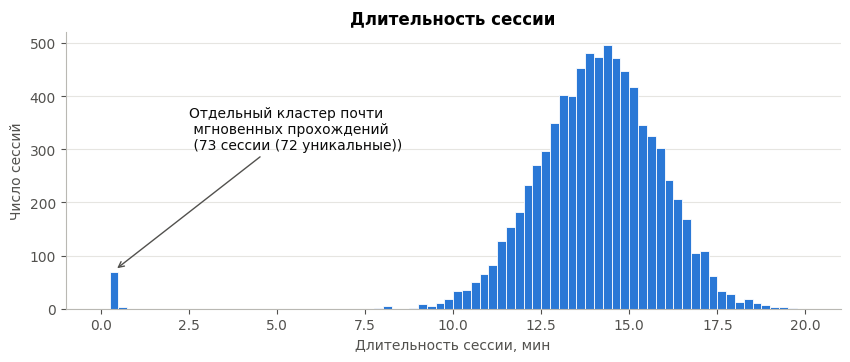

In [8]:
start_raw = pd.to_datetime(raw['start_time'], errors='coerce')
end_raw = pd.to_datetime(raw['end_time'], errors='coerce')
dur_raw = (end_raw - start_raw).dt.total_seconds()

time_checks = pd.Series({
    'Дат проведения': start_raw.dt.date.nunique(),
    'end_time ≤ start_time': (dur_raw <= 0).sum(),
    'Сумма Task_N_time_spent ≠ длительности сессии': (~np.isclose(raw[TIME].fillna(0).sum(axis=1), dur_raw)).sum(),
    'Аномальных сессий': (dur_raw < 150).sum(),
}, name='значение')
display(time_checks.to_frame())
print('Старты:', start_raw.min(), '-', start_raw.max(), '| Последнее окончание:', end_raw.max())

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.hist(dur_raw / 60, bins=np.arange(0, 20.25, 0.25), color=BLUE, edgecolor='white', linewidth=0.6)
n_fast = int((dur_raw < 120).sum())
n_fast_unique = int(raw.loc[dur_raw < 120].drop_duplicates().shape[0])
ax.annotate(f'Отдельный кластер почти \n мгновенных прохождений \n ({n_fast} сессии ({n_fast_unique} уникальные))', xy=(0.4, n_fast), xytext=(2.5, 300),
            arrowprops=dict(arrowstyle='->', color=MUTED), color=INK)
ax.set(xlabel='Длительность сессии, мин', ylabel='Число сессий')
ax.set_title('Длительность сессии')
plt.show()

### 1.7 Итоги первичного осмотра

| # | Проблема | Масштаб | Решение |
|---|---|---|---|
| 1 | Полные дубликаты строк | 37 строк | удалить |
| 2 | Разные написания регионов | 9 лишних вариантов, 259 строк | нормализовать к 10 регионам |
| 3 | Сверхбыстрые сессии: 1-3 сек на задание | 72 сессии | удалить как тестовые или бот-сессии |
| 4 | Пропуски в заданиях | 3 775 ячеек-заданий, ~38 % учеников | не заполнять средним: это пропуск задания = 0 баллов, отметить флагом |
| 5 | Типы: даты - строки, задания - float | - | привести к datetime, Int64 |

<a id="2"></a>
## 2. Очистка данных

### 2.1 Удаление дубликатов

In [9]:
df = raw.copy()
df = df.drop_duplicates().reset_index(drop=True)
print(f'Удалено дубликатов: {len(raw) - len(df)}; осталось строк: {len(df)}; '
      f'student_id уникален: {df["student_id"].is_unique}')

Удалено дубликатов: 37; осталось строк: 8000; student_id уникален: True


### 2.2 Названия регионов
Исправляем опечатки с помощью словаря ошибок. Если появится нераспознанное
название, сработает `assert`: так новые опечатки не пройдут в аналитику незамеченными.

In [10]:
REGIONS = ['Москва', 'Санкт-Петербург', 'Воронеж', 'Краснодар', 'Ростов-на-Дону',
           'Казань', 'Екатеринбург', 'Пермь', 'Уфа', 'Новосибирск']

error_dict = {
    'г.Казань': 'Казань', 'казань': 'Казань',
    'СПб': 'Санкт-Петербург', 'спб': 'Санкт-Петербург', 'Санкт Петербург': 'Санкт-Петербург',
    'мск': 'Москва', 'москва': 'Москва', 'г. Москва': 'Москва', 'Moskva': 'Москва'
}

before = df['region'].nunique()
df['region'] = df['region'].replace(error_dict)

unknown = set(df['region'].dropna()) - set(REGIONS)
assert not unknown, f'Нераспознанные регионы: {unknown}'

counts = df['region'].value_counts(dropna=False).rename_axis('Регион').to_frame('Участников')
display(counts.T)
print(f'Написаний было: {before}; стало: {df["region"].nunique()}')

Регион,Уфа,Москва,Казань,Краснодар,Воронеж,Санкт-Петербург,Ростов-на-Дону,Новосибирск,Пермь,Екатеринбург
Участников,843,830,821,806,803,801,796,786,763,751


Написаний было: 19; стало: 10


### 2.3 Приведение типов

In [11]:
df['start_time'] = pd.to_datetime(df['start_time'])
df['end_time'] = pd.to_datetime(df['end_time'])
df['duration_sec'] = (df['end_time'] - df['start_time']).dt.total_seconds()

### 2.4 Аномальные сессии
У 72 сессий длительность 18–31 секунда, то есть 1–3 секунды на задание, и при этом отвечены все 12 заданий.
Следующая по длительности сессия длится почти 8 минут: между группами большой разрыв, поэтому порог 2,5 минуты
не срезает реальных участников. Проверим, похожи ли быстрые ответы на случайное угадывание (вариантов 4, значит ожидаем ~25 % верных).

In [12]:
is_fast = df['duration_sec'] < 150
print(f'Самая долгая аномальная сессия: {df.loc[is_fast, "duration_sec"].max():.0f} сек; '
      f'самая короткая обычная: {df.loc[~is_fast, "duration_sec"].min():.0f} сек')

answered = df[ANS].notna()
compare = pd.DataFrame({
    'Сессий': [is_fast.sum(), (~is_fast).sum()],
    'Длительность, мин (медиана)': [df.loc[is_fast, 'duration_sec'].median() / 60,
                                   df.loc[~is_fast, 'duration_sec'].median() / 60],
    'Макс. время на задание, сек': [df.loc[is_fast, TIME].max().max(), df.loc[~is_fast, TIME].max().max()],
    'Отвечено заданий (среднее)': [answered[is_fast].sum(axis=1).mean(), answered[~is_fast].sum(axis=1).mean()],
    'Доля верных ответов, %': [df.loc[is_fast, 'total_score'].sum() / answered[is_fast].sum().sum() * 100,
                               df.loc[~is_fast, 'total_score'].sum() / answered[~is_fast].sum().sum() * 100],
}, index=['Сверхбыстрые (< 2,5 мин)', 'Остальные'])
display(compare)

k = int(df.loc[is_fast, 'total_score'].sum())
n = int(answered[is_fast].sum().sum())
bt = stats.binomtest(k, n, p=0.25)
print(f'Биномиальный тест «доля верных = 25 % (угадывание)»: p-value = {bt.pvalue:.3f} - '
      f'{"не отличается от случайного угадывания" if bt.pvalue > 0.05 else "отличается"}')

before = len(df)
df = df.loc[~is_fast].reset_index(drop=True)
print(f'Удалено аномальных сессий: {before - len(df)}; осталось строк: {len(df)}')

Самая долгая аномальная сессия: 31 сек; самая короткая обычная: 470 сек


,Сессий,"Длительность, мин (медиана)","Макс. время на задание, сек",Отвечено заданий (среднее),"Доля верных ответов, %"
"Сверхбыстрые (< 2,5 мин)",72,0.40,3.00,12.00,23.15
Остальные,7928,14.15,191.00,11.53,48.13


Биномиальный тест «доля верных = 25 % (угадывание)»: p-value = 0.223 - не отличается от случайного угадывания
Удалено аномальных сессий: 72; осталось строк: 7928


В сверхбыстрых сессиях есть ответы на все 12 заданий за 1–3 секунды каждое, и доля верных ответов у них статистически
не отличается от случайного угадывания. Это автоматизированные или тестовые прохождения (проверка платформы разработчиками,
боты). Они занижают средние баллы и искажают время, поэтому **удаляем их**.

### 2.5 Пропущенные задания и «мгновенные» ответы
* Пропуск задания означает, что ученик его не решал. В `total_score` оно уже засчитано как 0. **Заполнять средним нельзя:**
  так мы приписали бы ученику ответ, которого не было. Поэтому `Task_N_correct = 0`, `Task_N_time_spent = 0`
  (сумма времени по заданиям тогда точно равна длительности сессии), а `Task_N_answer` остаётся пустым как признак пропуска.
* Минимальное время на задание - ровно 5 секунд, и на этом значении всплеск (350 ответов против 40–50 на соседних). Похоже, платформа не логирует время меньше 5 секунд. Такие ответы оставлены в данных: они разбросаны по 344 разным ученикам с обычной длительностью сессии, то есть это живые участники, а не боты. Такие ответы помечаем как «мгновенные» (`n_instant`).

In [13]:
INSTANT_SEC = 5

print('Распределение времени на задание (сек), самые частые малые значения:')
print(pd.Series(df[TIME].stack()).value_counts().sort_index().head(8).to_dict())

df[COR] = df[COR].fillna(0).astype('Int64')
df[TIME] = df[TIME].fillna(0).astype('Int64')
df[ANS] = df[ANS].astype('Int64')
for col in ['school_number', 'grade', 'attempts_count', 'disconnects']:
    df[col] = df[col].astype(int)

Распределение времени на задание (сек), самые частые малые значения:
{5.0: 350, 6.0: 40, 7.0: 43, 8.0: 47, 9.0: 67, 10.0: 67, 11.0: 57, 12.0: 89}


In [14]:
print(f'Итого: {len(raw)} строк -> {len(df)} участников (удалено {len(raw) - len(df)} записей)')

Итого: 8037 строк -> 7928 участников (удалено 109 записей)


<a id="3"></a>
## 3. Обогащение данных: производные метрики

| Метрика | Описание |
|---|---|
| `n_answered`, `n_skipped`, `completed_all` | сколько заданий решил, пропустил, прошёл ли все 12 |
| `accuracy_answered_pct` | доля верных среди отвеченных заданий |
| `duration_min` | длительность сессии, мин |
| `avg_time_per_task` | **среднее время решения одной задачи** (сек на отвеченное задание) |
| `n_instant` | число «мгновенных» ответов (≤ 5 сек) |
| `is_high` | высокий результат - 9+ баллов из 12 |
| `had_disconnect` | были ли разрывы соединения |
| `utc_offset`, `tz_group` | часовой пояс региона (МСК, МСК+2, МСК+4) |
| `start_hour` | час старта сессии |

In [15]:
REGION_UTC = {'Москва': 3, 'Санкт-Петербург': 3, 'Воронеж': 3, 'Краснодар': 3, 'Ростов-на-Дону': 3,
              'Казань': 3, 'Екатеринбург': 5, 'Пермь': 5, 'Уфа': 5, 'Новосибирск': 7}
HIGH_SCORE = 9

answered = df[ANS].notna()
df['n_answered'] = answered.sum(axis=1)
df['n_skipped'] = N_TASKS - df['n_answered']
df['completed_all'] = df['n_skipped'].eq(0)
df['accuracy_answered_pct'] = df['total_score'] / df['n_answered'] * 100
df['duration_min'] = df['duration_sec'] / 60
df['avg_time_per_task'] = df['duration_sec'] / df['n_answered']
df['n_instant'] = ((df[TIME].to_numpy() <= INSTANT_SEC) & answered.to_numpy()).sum(axis=1)
df['is_high'] = df['total_score'] >= HIGH_SCORE
df['had_disconnect'] = df['disconnects'] > 0
df['utc_offset'] = df['region'].map(REGION_UTC)
df['tz_group'] = df['utc_offset'].map({3: 'МСК', 5: 'МСК+2', 7: 'МСК+4'})
df['start_hour'] = df['start_time'].dt.hour

derived = ['n_answered', 'n_skipped', 'accuracy_answered_pct', 'duration_min',
           'avg_time_per_task', 'n_instant']
DERIVED_RU = {
    'n_answered': 'Отвечено заданий',
    'n_skipped': 'Пропущено заданий',
    'accuracy_answered_pct': 'Точность среди отвеченных, %',
    'duration_min': 'Длительность сессии, мин',
    'avg_time_per_task': 'Время на задание, сек',
    'n_instant': 'Мгновенных ответов (до 5 сек)',
}
display(df[derived].describe().T[['mean', 'std', 'min', '50%', 'max']]
        .rename(index=DERIVED_RU)
        .rename(columns={'mean': 'среднее', 'std': 'ст. отклонение', 'min': 'минимум',
                         '50%': 'медиана', 'max': 'максимум'})
        .rename_axis('Метрика')
        .round(2))

,среднее,ст. отклонение,минимум,медиана,максимум
Метрика,,,,,
Отвечено заданий,11.53,0.67,8.00,12.00,12.00
Пропущено заданий,0.47,0.67,0.00,0.00,4.00
"Точность среди отвеченных, %",48.13,23.97,0.00,50.00,100.00
"Длительность сессии, мин",14.12,1.63,7.83,14.15,19.57
"Время на задание, сек",73.50,7.35,47.00,73.42,101.55
Мгновенных ответов (до 5 сек),0.04,0.21,0.00,0.00,2.00


In [16]:
df.to_csv(CLEAN_PATH, index=False, encoding='utf-8-sig')
print(f'Очищенный датасет сохранён: {CLEAN_PATH} - {df.shape[0]:} строк × {df.shape[1]} столбцов')

Очищенный датасет сохранён: data\olympiad_results_clean.csv - 7928 строк × 59 столбцов


### Общая картина результатов

,
Участников,7 928
Регионов / школ,10 / 590
Средний балл,5.55 из 12 (46%)
Медиана,6
Высокий результат (9+),16.3%
Прошли все 12 заданий,61.6%
Среднее время на задание,74 сек
Средняя длительность,14.1 мин


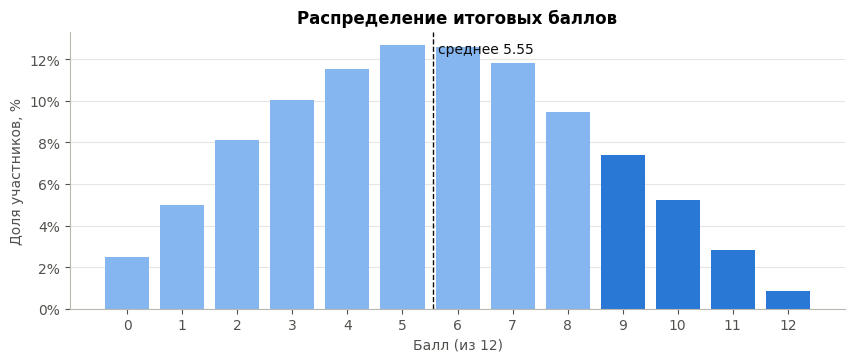

In [17]:
overall_mean = df['total_score'].mean()
kpi = pd.Series({
    'Участников': f"{len(df):,}".replace(',', ' '),
    'Регионов / школ': f"{df['region'].nunique()} / {df.groupby(['region', 'school_number']).ngroups}",
    'Средний балл': f"{overall_mean:.2f} из 12 ({overall_mean / 12:.0%})",
    'Медиана': f"{df['total_score'].median():.0f}",
    'Высокий результат (9+)': f"{df['is_high'].mean():.1%}",
    'Прошли все 12 заданий': f"{df['completed_all'].mean():.1%}",
    'Среднее время на задание': f"{df['avg_time_per_task'].mean():.0f} сек",
    'Средняя длительность': f"{df['duration_min'].mean():.1f} мин",
}, name='')
display(kpi.to_frame())

dist = df['total_score'].value_counts(normalize=True).sort_index() * 100
fig, ax = plt.subplots(figsize=(10, 3.6))
colors = [BLUE if s >= HIGH_SCORE else '#86b6ef' for s in dist.index]
ax.bar(dist.index, dist.values, color=colors, width=0.8)
ax.axvline(overall_mean, color=INK, lw=1, ls='--')
ax.text(overall_mean + 0.1, dist.max() * 0.97, f'среднее {overall_mean:.2f}', color=INK)
ax.set(title='Распределение итоговых баллов', xlabel='Балл (из 12)', ylabel='Доля участников, %', xticks=range(0, 13))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
plt.show()

<a id="4"></a>
## 4. Сложность заданий
Для каждого задания считаем:
* **решаемость**: доля верных ответов среди всех участников (пропуск = неверно) и среди тех, кто к заданию приступил;
* **долю пропусков** и **среднее время** (только по отвеченным);
* **долю «мгновенных» ответов** (≤ 5 сек);
* **дискриминативность**: корреляцию верного ответа на задание с баллом за *остальные* задания.
  Чем она выше, тем лучше задание отделяет сильных участников от слабых.

In [18]:
def task_solve_rate(data):
    # доля верных ответов на каждое задание среди всех участников, %
    return pd.Series(data[COR].astype(float).mean().to_numpy() * 100, index=TASKS)

answered = df[ANS].notna().to_numpy()
cor = df[COR].astype(float).to_numpy()
tim = df[TIME].astype(float).to_numpy()
rest = df['total_score'].to_numpy()[:, None] - cor

task_stats = pd.DataFrame({
    'Решаемость, %': task_solve_rate(df),
    'Решаемость среди приступивших, %': np.nanmean(np.where(answered, cor, np.nan), axis=0) * 100,
    'Пропуски, %': (~answered).mean(axis=0) * 100,
    'Среднее время, сек': np.nanmean(np.where(answered, tim, np.nan), axis=0),
    'Мгновенные ответы, %': ((tim <= INSTANT_SEC) & answered).sum(axis=0) / answered.sum(axis=0) * 100,
    'Дискриминативность': [np.corrcoef(cor[:, j], rest[:, j])[0, 1] for j in range(N_TASKS)],
}, index=pd.Index(TASKS, name='Задание'))
task_stats['Сложность'] = pd.cut(task_stats['Решаемость, %'], bins=[0, 35, 50, 100],
                                 labels=['сложное', 'среднее', 'лёгкое'])
task_stats = task_stats.sort_values('Решаемость, %')
num_cols = [c for c in task_stats.columns if c not in ('Дискриминативность', 'Сложность')]
display(task_stats.style.format('{:.1f}', subset=num_cols).format('{:.3f}', subset=['Дискриминативность'])
        .background_gradient(subset=['Решаемость, %'], cmap=SEQ_CMAP))

,"Решаемость, %","Решаемость среди приступивших, %","Пропуски, %","Среднее время, сек","Мгновенные ответы, %",Дискриминативность,Сложность
Задание,,,,,,,
1,28.6,29.8,4.0,64.1,0.9,0.317,сложное
9,30.7,32.0,3.9,65.9,0.8,0.328,сложное
3,32.6,33.9,4.0,66.0,0.7,0.313,сложное
2,36.2,37.8,4.3,69.1,0.4,0.327,среднее
6,43.2,45.1,4.1,71.7,0.4,0.320,среднее
11,45.0,46.7,3.6,72.8,0.4,0.344,среднее
10,51.1,53.3,4.0,75.9,0.2,0.334,лёгкое
12,54.9,57.2,4.0,77.8,0.2,0.336,лёгкое
7,56.5,58.7,3.9,79.1,0.1,0.334,лёгкое


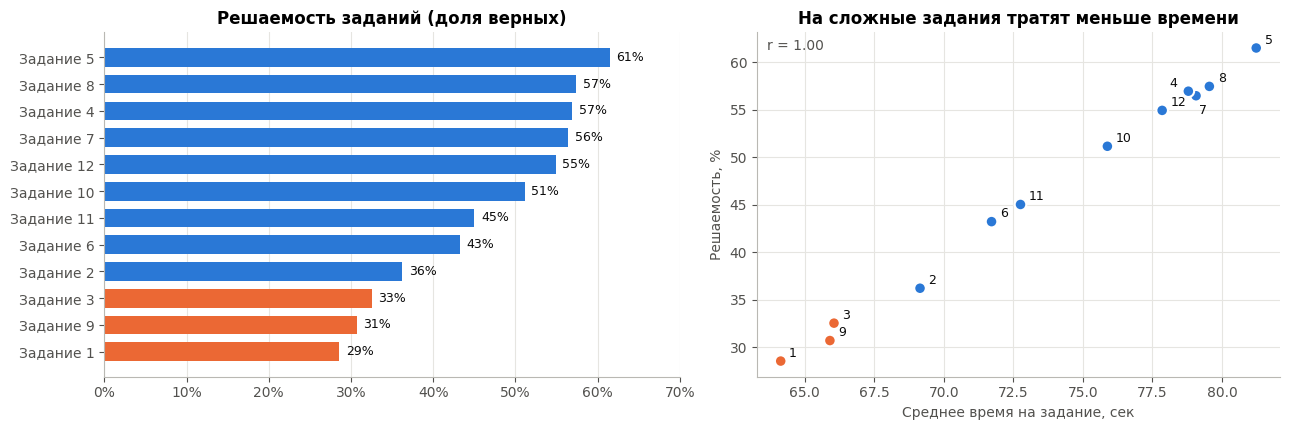

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={'width_ratios': [1.1, 1]})

ts = task_stats.sort_values('Решаемость, %')
hard = ts.index[:3]
ax = axes[0]
bar_colors = [ORANGE if t in hard else BLUE for t in ts.index]
ax.barh([f'Задание {t}' for t in ts.index], ts['Решаемость, %'], color=bar_colors, height=0.7)
for y, v in enumerate(ts['Решаемость, %']):
    ax.text(v + 0.8, y, f'{v:.0f}%', va='center', color=INK, fontsize=9)
ax.set(title='Решаемость заданий (доля верных)', xlim=(0, 70))
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.grid(axis='y', visible=False); ax.grid(axis='x', visible=True)

ax = axes[1]
ax.scatter(task_stats['Среднее время, сек'], task_stats['Решаемость, %'], s=70,
           c=[ORANGE if t in hard else BLUE for t in task_stats.index], edgecolor='white', linewidth=1.5, zorder=3)
label_offsets = {4: (-14, 3), 7: (2, -13), 8: (6, 3)}
for t, row in task_stats.iterrows():
    ax.annotate(str(t), (row['Среднее время, сек'], row['Решаемость, %']), xytext=label_offsets.get(t, (6, 3)),
                textcoords='offset points', fontsize=9, color=INK)
r_time = stats.pearsonr(task_stats['Среднее время, сек'], task_stats['Решаемость, %'])
ax.set(title='На сложные задания тратят меньше времени',
       xlabel='Среднее время на задание, сек', ylabel='Решаемость, %')
ax.text(0.02, 0.95, f'r = {r_time.statistic:.2f}', transform=ax.transAxes, color=MUTED)
ax.grid(axis='x', visible=True)
fig.tight_layout()
plt.show()

In [20]:
# Время у ответивших верно и неверно: сложные задания «короче» для всех или только для ошибающихся?
time_by_outcome = pd.DataFrame({
    'Верно, сек': [df.loc[answered[:, j] & (cor[:, j] == 1), TIME[j]].astype(float).mean() for j in range(N_TASKS)],
    'Неверно, сек': [df.loc[answered[:, j] & (cor[:, j] == 0), TIME[j]].astype(float).mean() for j in range(N_TASKS)],
}, index=pd.Index(TASKS, name='Задание')).loc[task_stats.index]
time_by_outcome['Разница, сек'] = time_by_outcome['Верно, сек'] - time_by_outcome['Неверно, сек']
print('Среднее время на задание, сек (задания от сложных к лёгким):')
display(time_by_outcome.T.round(1))

Среднее время на задание, сек (задания от сложных к лёгким):


Задание,1,9,3,2,6,11,10,12,7,4,8,5
"Верно, сек",63.60,66.20,66.30,68.70,71.60,72.90,75.50,77.80,79.00,78.40,79.80,81.10
"Неверно, сек",64.30,65.80,65.90,69.40,71.80,72.70,76.30,77.90,79.20,79.40,79.20,81.50
"Разница, сек",-0.70,0.40,0.40,-0.70,-0.20,0.20,-0.70,-0.10,-0.30,-1.00,0.50,-0.40


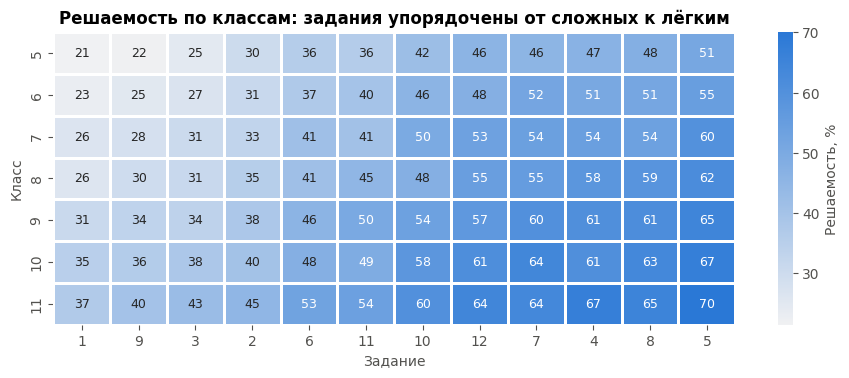

In [21]:
grade_task = df.groupby('grade')[COR].mean().astype(float) * 100
grade_task.columns = TASKS
order = task_stats.index  # от сложных к лёгким

fig, ax = plt.subplots(figsize=(11, 3.8))
sns.heatmap(grade_task[order], annot=True, fmt='.0f', cmap=SEQ_CMAP, cbar_kws={'label': 'Решаемость, %'},
            linewidths=1, linecolor='white', ax=ax, annot_kws={'fontsize': 9})
ax.set(title='Решаемость по классам: задания упорядочены от сложных к лёгким',
       xlabel='Задание', ylabel='Класс')
ax.grid(False)
plt.show()

**Выводы по заданиям**
* **Самые сложные задания - 1, 9 и 3** (решаемость 29-33%), **самые лёгкие - 5, 8 и 4** (57-61%).
  Разброс сложности хороший: из 12 заданий нет ни нерешаемых, ни тривиальных.
* **На сложные задания тратят меньше времени, а не больше:** связь среднего времени и решаемости почти линейная (r ≈ 1,0). Внутри задания верно и неверно ответившие тратят одинаковое время. На сложных заданиях в 5-8 раз больше «мгновенных» ответов (≤ 5 сек).
  Вероятное объяснение: трудную задачу не пытаются решить до конца, а быстро ставят ответ. Это стоит проверить
  с методистами: возможно, формулировка или порог входа отпугивают.
* Порядок сложности **одинаков во всех классах**, 11-классники решают каждое задание на 16-20 процентных пунктов лучше 5-классников.
  Олимпиада единая для всех классов, поэтому самые сложные задачи младшим почти недоступны: в 5 классе
  решаемость заданий 1 и 9 - 22-23%, около уровня угадывания (25%).
* Все задания одинаково умеренно отделяют сильных участников от слабых (дискриминативность 0,31-0,34):
  заданий, которые одинаково решают сильные и слабые, нет.

<a id="5"></a>
## 5. Аудитория олимпиады

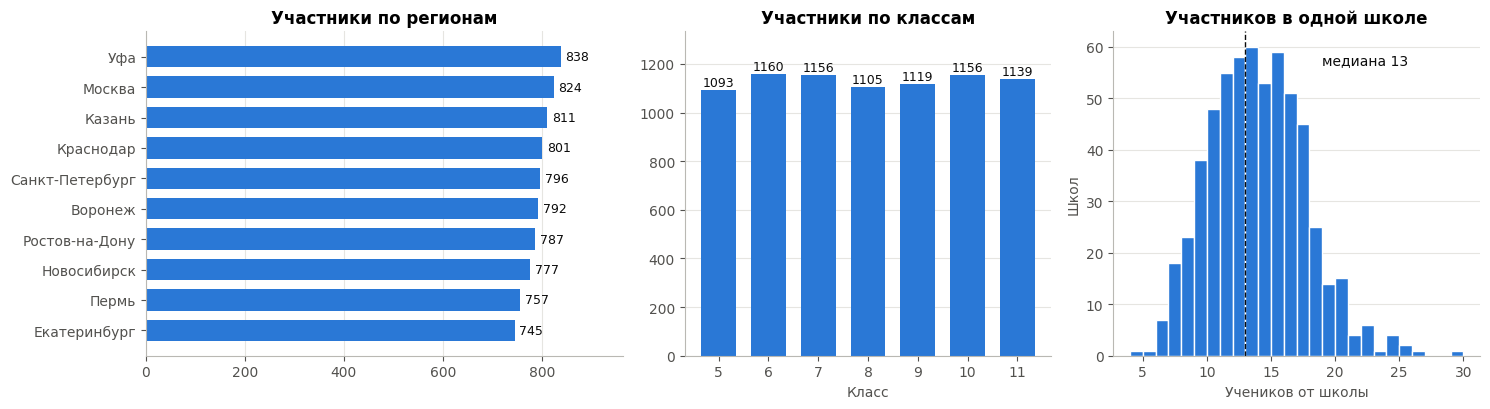

Школ всего: 590 (по [59] в каждом регионе); учеников от школы: от 4 до 29, медиана 13


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), gridspec_kw={'width_ratios': [1.3, 1, 1]})

reg_n = df['region'].value_counts().sort_values()
ax = axes[0]
ax.barh(reg_n.index, reg_n.values, color=BLUE, height=0.7)
for y, v in enumerate(reg_n.values):
    ax.text(v + 10, y, f'{v}', va='center', fontsize=9, color=INK)
ax.set(title='Участники по регионам', xlim=(0, reg_n.max() * 1.15))
ax.grid(axis='y', visible=False); ax.grid(axis='x', visible=True)

gr_n = df['grade'].value_counts().sort_index()
ax = axes[1]
ax.bar(gr_n.index.astype(str), gr_n.values, color=BLUE, width=0.7)
for x, v in enumerate(gr_n.values):
    ax.text(x, v + 15, f'{v}', ha='center', fontsize=9, color=INK)
ax.set(title='Участники по классам', xlabel='Класс', ylim=(0, gr_n.max() * 1.15))

school_n = df.groupby(['region', 'school_number']).size()
ax = axes[2]
ax.hist(school_n, bins=range(school_n.min(), school_n.max() + 2), color=BLUE, edgecolor='white')
ax.axvline(school_n.median(), color=INK, ls='--', lw=1)
ax.text(school_n.median() + 6, ax.get_ylim()[1] * 0.9, f'медиана {school_n.median():.0f}', color=INK)
ax.set(title='Участников в одной школе', xlabel='Учеников от школы', ylabel='Школ')
fig.tight_layout()
plt.show()

print(f'Школ всего: {len(school_n)} (по {df.groupby("region")["school_number"].nunique().unique()} в каждом регионе); '
      f'учеников от школы: от {school_n.min()} до {school_n.max()}, медиана {school_n.median():.0f}')

In [23]:
aud = pd.crosstab(df['region'], df['grade'], margins=True, margins_name='Всего')
display(Markdown('**Сводная таблица: участники по регионам и классам**'))
display(aud)

dev = pd.crosstab(df['region'], df['device_type'], normalize='index') * 100
dev.loc['Все регионы'] = df['device_type'].value_counts(normalize=True) * 100
display(Markdown('**Устройства прохождения, % участников**'))
display(dev.round(1))

**Сводная таблица: участники по регионам и классам**

grade,5,6,7,8,9,10,11,Всего
region,,,,,,,,
Воронеж,112,125,110,125,126,91,103,792
Екатеринбург,91,102,108,107,115,118,104,745
Казань,122,127,114,107,114,118,109,811
Краснодар,109,120,104,101,105,139,123,801
Москва,128,110,122,115,134,107,108,824
Новосибирск,99,113,102,108,116,120,119,777
Пермь,114,106,127,92,97,99,122,757
Ростов-на-Дону,98,98,131,132,99,114,115,787
Санкт-Петербург,95,138,110,118,101,126,108,796


**Устройства прохождения, % участников**

device_type,desktop,mobile,tablet
region,,,
Воронеж,56.80,37.00,6.20
Екатеринбург,60.90,33.70,5.40
Казань,58.60,36.40,5.10
Краснодар,57.40,38.50,4.10
Москва,57.20,37.00,5.80
Новосибирск,60.50,34.90,4.60
Пермь,62.20,33.70,4.10
Ростов-на-Дону,60.50,34.30,5.20
Санкт-Петербург,58.30,36.70,5.00


**Выводы по аудитории**
* 7 928 участников из 590 школ (по 59 в каждом регионе), в среднем 13 учеников от школы.
* Регионы представлены равномерно: 745-838 участников от региона (≈10% от общего числа), больше всего в Уфе, меньше всего в Екатеринбурге.
* Классы представлены тоже равномерно: 1 093-1 160 участников на параллель. Нет «провала» ни у младших, ни у выпускников.
* **Устройства:** 60% проходят с компьютера, 35% с телефона, 5% с планшета. Больше трети аудитории
  решает олимпиаду с телефона, поэтому мобильная версия продукта тоже критически важна.

<a id="6"></a>
## 6. Вовлечённость и результаты по классам
Вовлечённость оцениваем по поведению участника: сколько заданий он решал (доля прошедших все 12, пропуски),
сколько времени тратил на задание и как часто отвечал «мгновенно».

In [24]:
def mean_ci(s):
    return 1.96 * s.std() / np.sqrt(len(s))

by_grade = df.groupby('grade').agg(
    participants=('student_id', 'size'),
    mean_score=('total_score', 'mean'),
    ci=('total_score', mean_ci),
    high_share=('is_high', 'mean'),
    completion=('completed_all', 'mean'),
    skipped=('n_skipped', 'mean'),
    avg_time=('avg_time_per_task', 'mean'),
    instant=('n_instant', 'mean'),
    accuracy=('accuracy_answered_pct', 'mean'),
)
by_grade['share'] = by_grade['participants'] / len(df) * 100
by_grade[['high_share', 'completion']] *= 100
by_grade_view = by_grade.rename(columns={
    'participants': 'Участников', 'share': 'Доля, %', 'mean_score': 'Средний балл', 'ci': '±95% ДИ',
    'high_share': 'Высокий результат, %', 'completion': 'Прошли все 12, %', 'skipped': 'Пропусков на ученика',
    'avg_time': 'Сек на задание', 'instant': 'Мгновенных ответов', 'accuracy': 'Точность отвеченных, %'})
display(by_grade_view)

chi2 = stats.chi2_contingency(pd.crosstab(df['grade'], df['completed_all']))
print(f'Хи-квадрат «доля прошедших все задания зависит от класса»: p-value = {chi2.pvalue:.3f}')
rho = stats.spearmanr(df['grade'], df['total_score'])
print(f'Корреляция Спирмена «класс - балл»: rho = {rho.statistic:.3f}, p-value = {rho.pvalue:.1e}')

,Участников,Средний балл,±95% ДИ,"Высокий результат, %","Прошли все 12, %",Пропусков на ученика,Сек на задание,Мгновенных ответов,"Точность отвеченных, %","Доля, %"
grade,,,,,,,,,,
5,1093,4.50,0.16,9.61,61.94,0.48,73.63,0.05,38.96,13.79
6,1160,4.85,0.15,9.74,61.98,0.47,73.47,0.04,42.10,14.63
7,1156,5.26,0.15,12.37,60.81,0.47,73.48,0.05,45.66,14.58
8,1105,5.46,0.16,14.03,61.45,0.48,73.51,0.04,47.39,13.94
9,1119,5.91,0.16,19.48,59.96,0.50,73.41,0.04,51.36,14.11
10,1156,6.21,0.16,21.97,60.99,0.48,73.58,0.04,53.87,14.58
11,1139,6.62,0.16,26.60,63.74,0.44,73.45,0.05,57.27,14.37


Хи-квадрат «доля прошедших все задания зависит от класса»: p-value = 0.665
Корреляция Спирмена «класс - балл»: rho = 0.246, p-value = 2.3e-109


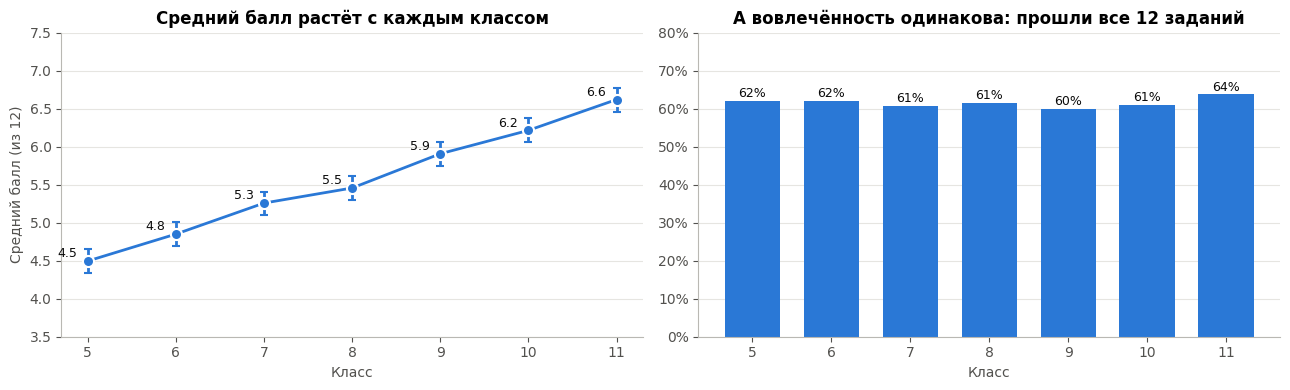

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
ax.errorbar(by_grade.index, by_grade['mean_score'], yerr=by_grade['ci'], color=BLUE, lw=2,
            marker='o', ms=8, mec='white', mew=1.5, capsize=3)
for g, v in by_grade['mean_score'].items():
    ax.text(g - 0.12, v + 0.05, f'{v:.1f}', ha='right', color=INK, fontsize=9)
ax.set(title='Средний балл растёт с каждым классом', xlabel='Класс', ylabel='Средний балл (из 12)', ylim=(3.5, 7.5))

ax = axes[1]
ax.bar(by_grade.index.astype(str), by_grade['completion'], color=BLUE, width=0.7)
for x, v in enumerate(by_grade['completion']):
    ax.text(x, v + 1, f'{v:.0f}%', ha='center', fontsize=9, color=INK)
ax.set(title='А вовлечённость одинакова: прошли все 12 заданий', xlabel='Класс', ylim=(0, 80))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
fig.tight_layout()
plt.show()

In [26]:
by_device = df.groupby('device_type').agg(
    participants=('student_id', 'size'), mean_score=('total_score', 'mean'),
    completion=('completed_all', 'mean'), avg_time=('avg_time_per_task', 'mean'),
    disconnect_share=('had_disconnect', 'mean'), attempts=('attempts_count', 'mean'))
by_device[['completion', 'disconnect_share']] *= 100
display(by_device.rename(columns={'participants': 'Участников', 'mean_score': 'Средний балл',
                                  'completion': 'Прошли все 12, %', 'avg_time': 'Сек на задание',
                                  'disconnect_share': 'Были разрывы, %', 'attempts': 'Попыток входа'}))

,Участников,Средний балл,"Прошли все 12, %",Сек на задание,"Были разрывы, %",Попыток входа
device_type,,,,,,
desktop,4710,5.53,61.85,73.47,16.96,1.50
mobile,2813,5.57,60.97,73.63,18.34,1.49
tablet,405,5.60,62.22,73.07,17.53,1.50


**Выводы по вовлечённости**
* **Вовлечённость одинаково высокая во всех классах.** Все 12 заданий прошли 60-64% участников в каждой параллели,
  пропусков около 0,5 на ученика, время на задание около 73 сек. Статистически значимых различий между классами нет
  (хи-квадрат, p > 0,05). Младшие школьники не бросают олимпиаду чаще старших.
* **Результат при этом сильно зависит от класса:** средний балл растёт монотонно, от 4,5 в 5 классе до 6,6 в 11 классе
  (+47%). Доля высоких результатов (9+) в 11 классе примерно в 3 раза выше, чем в 5.
  Для 5-6 классов олимпиада трудная: при той же вовлечённости они набирают заметно меньше.
* **Устройство не влияет** ни на балл, ни на завершение: компьютер, телефон и планшет дают одинаковые результаты.
  Разрывы связи бывают у ~17% участников на любом устройстве.

<a id="7"></a>
## 7. Региональная аналитика и мини-отчёты
### 7.1 Сравнение регионов

In [27]:
def region_summary(data):
    s = data.groupby('region').agg(
        participants=('student_id', 'size'),
        schools=('school_number', 'nunique'),
        mean_score=('total_score', 'mean'),
        ci=('total_score', mean_ci),
        median_score=('total_score', 'median'),
        high_share=('is_high', 'mean'),
        completion=('completed_all', 'mean'),
        avg_time=('avg_time_per_task', 'mean'),
        disconnect_share=('had_disconnect', 'mean'),
        mobile_share=('device_type', lambda x: (x != 'desktop').mean()),
    )
    s['per_school'] = s['participants'] / s['schools']
    s[['high_share', 'completion', 'disconnect_share', 'mobile_share']] *= 100
    s['rank'] = s['mean_score'].rank(ascending=False, method='min').astype(int)
    return s.sort_values('mean_score', ascending=False)


REGION_COLS = {'participants': 'Участников', 'schools': 'Школ', 'per_school': 'Учеников на школу',
               'mean_score': 'Средний балл', 'ci': '±95% ДИ', 'median_score': 'Медиана',
               'high_share': 'Высокий результат, %', 'completion': 'Прошли все 12, %',
               'avg_time': 'Сек на задание', 'disconnect_share': 'Были разрывы, %',
               'mobile_share': 'С телефона/планшета, %', 'rank': 'Место'}

reg = region_summary(df)
reg_view = reg.rename(columns=REGION_COLS)
display(reg_view.style
        .format('{:.1f}', subset=['Учеников на школу', 'Высокий результат, %', 'Прошли все 12, %', 'Сек на задание',
                                  'Были разрывы, %', 'С телефона/планшета, %', 'Медиана'])
        .format('{:.2f}', subset=['Средний балл', '±95% ДИ'])
        .background_gradient(subset=['Средний балл'], cmap=SEQ_CMAP))

,Участников,Школ,Средний балл,±95% ДИ,Медиана,"Высокий результат, %","Прошли все 12, %",Сек на задание,"Были разрывы, %","С телефона/планшета, %",Учеников на школу,Место
region,,,,,,,,,,,,
Новосибирск,777,59,5.73,0.20,6.0,19.3,61.8,73.9,17.2,39.5,13.2,1
Москва,824,59,5.66,0.19,6.0,17.4,58.1,73.7,18.8,42.8,14.0,2
Екатеринбург,745,59,5.62,0.20,6.0,15.7,62.4,73.5,17.9,39.1,12.6,3
Ростов-на-Дону,787,59,5.60,0.20,6.0,16.8,61.6,74.0,18.4,39.5,13.3,4
Санкт-Петербург,796,59,5.58,0.19,6.0,16.2,64.2,73.0,18.1,41.7,13.5,5
Воронеж,792,59,5.50,0.19,6.0,15.2,63.5,73.4,17.4,43.2,13.4,6
Уфа,838,59,5.49,0.19,5.0,15.6,63.0,73.1,15.9,38.1,14.2,7
Казань,811,59,5.48,0.19,5.0,17.4,58.9,73.5,15.5,41.4,13.7,8
Краснодар,801,59,5.43,0.19,5.0,14.6,61.8,73.4,17.9,42.6,13.6,9


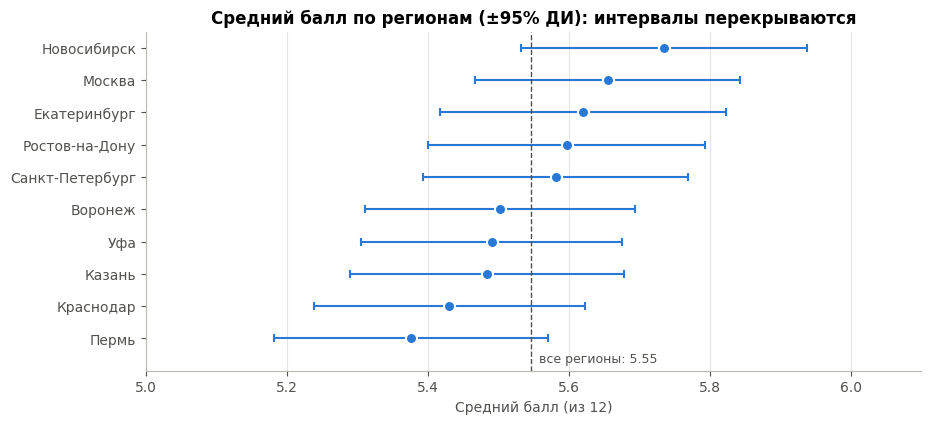

In [28]:
fig, ax = plt.subplots(figsize=(10, 4.4))
r = reg.sort_values('mean_score')
ax.errorbar(r['mean_score'], range(len(r)), xerr=r['ci'], fmt='o', color=BLUE, ms=8, mec='white',
            mew=1.5, capsize=3, lw=1.5)
ax.axvline(overall_mean, color=MUTED, ls='--', lw=1)
ax.text(overall_mean + 0.01, -0.75, f'все регионы: {overall_mean:.2f}', color=MUTED, fontsize=9)
ax.set_ylim(-1, len(r) - 0.5)
ax.set_yticks(range(len(r)), r.index)
ax.set(title='Средний балл по регионам (±95% ДИ): интервалы перекрываются', xlabel='Средний балл (из 12)',
       xlim=(5.0, 6.1))
ax.grid(axis='y', visible=False); ax.grid(axis='x', visible=True)
plt.show()

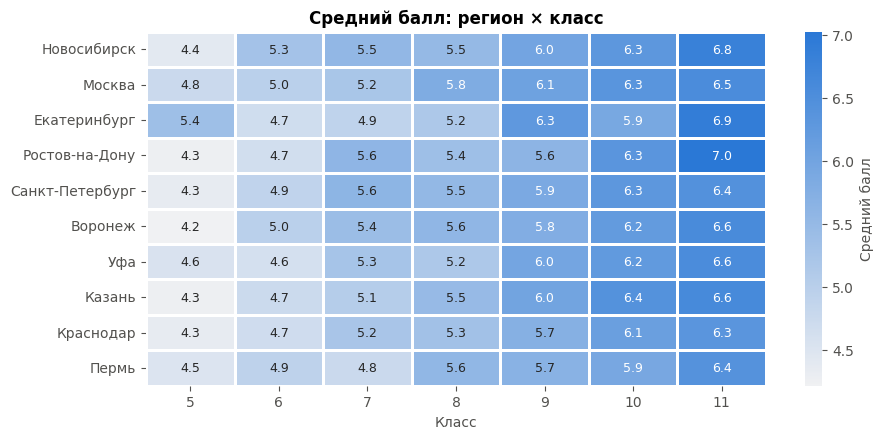

In [29]:
pivot = df.pivot_table(index='region', columns='grade', values='total_score', aggfunc='mean')
pivot = pivot.loc[reg.index]
fig, ax = plt.subplots(figsize=(10, 4.6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap=SEQ_CMAP, linewidths=1, linecolor='white',
            cbar_kws={'label': 'Средний балл'}, ax=ax, annot_kws={'fontsize': 9})
ax.set(title='Средний балл: регион × класс', xlabel='Класс', ylabel='')
ax.grid(False)
plt.show()

### 7.2 Школы
Рейтинг школ по среднему баллу строим только по школам, где **не меньше 10 участников**: при 4-5 учениках средний балл
слишком зависит от случайности. Для оценки «насколько школа выделяется» используем z-оценку: отклонение от общего
среднего в единицах стандартной ошибки. |z| > 3 означает, что результат вряд ли объясняется случайностью.

In [30]:
MIN_SCHOOL_N = 10
score_sd = df['total_score'].std()

def school_table(data):
    s = data.groupby(['region', 'school_number']).agg(
        participants=('student_id', 'size'), mean_score=('total_score', 'mean'),
        high_share=('is_high', 'mean'), avg_time=('avg_time_per_task', 'mean')).reset_index()
    s['high_share'] *= 100
    s['z'] = (s['mean_score'] - overall_mean) / (score_sd / np.sqrt(s['participants']))
    return s

SCHOOL_COLS = {'region': 'Регион', 'school_number': 'Школа №', 'participants': 'Участников',
               'mean_score': 'Средний балл', 'high_share': 'Высокий результат, %',
               'avg_time': 'Сек на задание', 'z': 'z-оценка'}

schools = school_table(df)
top_schools = (schools.query('participants >= @MIN_SCHOOL_N')
               .sort_values(['mean_score', 'participants'], ascending=False))
print(f'Школ с ≥ {MIN_SCHOOL_N} участниками: {len(top_schools)} из {len(schools)}')
display(Markdown('**Топ-10 школ по среднему баллу (все регионы)**'))
display(top_schools.head(10).rename(columns=SCHOOL_COLS).reset_index(drop=True))

Школ с ≥ 10 участниками: 502 из 590


**Топ-10 школ по среднему баллу (все регионы)**

,Регион,Школа №,Участников,Средний балл,"Высокий результат, %",Сек на задание,z-оценка
0,Ростов-на-Дону,13,20,7.95,45.00,75.59,3.86
1,Санкт-Петербург,11,12,7.92,50.00,73.08,2.95
2,Ростов-на-Дону,4,13,7.77,61.54,74.16,2.88
3,Москва,26,10,7.50,30.00,73.59,2.22
4,Новосибирск,52,10,7.50,30.00,70.11,2.22
5,Санкт-Петербург,56,10,7.40,30.00,71.00,2.11
6,Москва,4,14,7.36,35.71,76.08,2.43
7,Казань,5,21,7.29,42.86,74.17,2.86
8,Пермь,48,14,7.29,21.43,74.61,2.34
9,Новосибирск,6,12,7.25,33.33,72.55,2.12


**Различаются ли школы на самом деле?** Средний балл школы считается по ~13 ученикам, поэтому он сильно колеблется
случайно. Проверим, больше ли реальный разброс между школами, чем дал бы случай:
если школы не различаются, z-оценки распределены вокруг нуля, и |z| > 2 должно встречаться примерно у 4,6 % школ, |z| > 3 - у 0,3 %.

In [31]:
school_check = pd.Series({
    'Стандартное отклонение z-оценок (при случайности ≈ 1)': f"{schools['z'].std():.2f}",
    'Школ с |z| > 2: факт / ожидание при случайности': f"{(schools['z'].abs() > 2).sum()} / {len(schools) * 0.0455:.0f}",
    'Школ с |z| > 3: факт / ожидание при случайности': f"{(schools['z'].abs() > 3).sum()} / {len(schools) * 0.0027:.1f}",
}, name='')
display(school_check.to_frame())

,
Стандартное отклонение z-оценок (при случайности ≈ 1),0.99
Школ с |z| > 2: факт / ожидание при случайности,26 / 27
Школ с |z| > 3: факт / ожидание при случайности,1 / 1.6


**Разброс между школами не больше случайного.** Число «выделяющихся» школ совпадает с ожидаемым при чистой случайности, а разброс z-оценок близок к единице. Отсюда два следствия:
* рейтинг топ-школ в основном отражает удачу при маленькой выборке, а не качество подготовки.
  Использовать его как список «лучших школ» без повторных замеров нельзя;
* единственная школа с |z| > 3 (Ростов-на-Дону, №13) - тоже ожидаемый результат для 590 школ.
  Её стоит отслеживать на следующих турах, но пока это не доказанная аномалия.

Топ-школы в мини-отчётах ниже оставлены, потому что их требует формат отчёта, но читать их нужно с этой оговоркой.

### 7.3 Мини-отчёт по региону
`region_report(region)` формирует мини-отчёт по выбранному региону:
* **KPI**: участники, школы, средний балл и место среди регионов, доля высоких результатов, завершение, время, разрывы связи;
* **текстовые выводы**, сгенерированные автоматически (сильные и слабые задания, выделяющиеся школы);
* **топ-5 школ** (≥ 10 участников) и **таблицу по классам** в сравнении со всеми регионами;
* **4 графика**: распределение баллов, балл по классам, отклонение решаемости заданий от среднего, топ-10 школ.

In [32]:
REGION_SUMMARY = region_summary(df)
TASK_BASE = task_solve_rate(df)
GRADE_BASE = df.groupby('grade')['total_score'].mean()

def _region_kpi(region):
    s = REGION_SUMMARY.loc[region]
    return pd.Series({
        'Участников': int(s['participants']),
        'Школ': int(s['schools']),
        'Средний балл': f"{s['mean_score']:.2f} (все регионы: {overall_mean:.2f})",
        'Место по среднему баллу': f"{int(s['rank'])} из {len(REGION_SUMMARY)}",
        'Медиана': f"{s['median_score']:.0f}",
        'Высокий результат (9+)': f"{s['high_share']:.1f}% (все: {df['is_high'].mean() * 100:.1f}%)",
        'Прошли все 12 заданий': f"{s['completion']:.1f}% (все: {df['completed_all'].mean() * 100:.1f}%)",
        'Среднее время на задание': f"{s['avg_time']:.0f} сек",
        'Были разрывы связи': f"{s['disconnect_share']:.1f}%",
    }, name=region)

def _region_insights(region, r, tasks_diff, region_schools):
    s = REGION_SUMMARY.loc[region]
    diff = s['mean_score'] - overall_mean
    lines = [f"Средний балл {s['mean_score']:.2f} - {int(s['rank'])}-е место из {len(REGION_SUMMARY)} "
             f"({'+' if diff >= 0 else '−'}{abs(diff):.2f} к среднему по всем регионам)."]
    se = np.sqrt(TASK_BASE / 100 * (1 - TASK_BASE / 100) / len(r)) * 100
    notable = tasks_diff[tasks_diff.abs() > 2 * se].sort_values(key=abs, ascending=False)
    if len(notable) == 0:
        lines.append(f"Задания решают примерно так же, как в других регионах: отклонения от "
                     f"{tasks_diff.min():+.1f} до {tasks_diff.max():+.1f} п.п.")
    else:
        for t, v in notable.head(2).items():
            lines.append(f"Заметно выделяется задание {t}: решают на {abs(v):.1f} п.п. "
                         f"{'чаще' if v > 0 else 'реже'}, чем в других регионах.")

    g = r.groupby('grade')['total_score'].mean() - GRADE_BASE
    lines.append(f"Относительно той же параллели по всем регионам лучше всего выступил {g.idxmax()} класс "
                 f"({g.max():+.2f} балла), слабее всего - {g.idxmin()} класс ({g.min():+.2f}).")

    strong = region_schools.query('participants >= @MIN_SCHOOL_N and z > 3')
    weak = region_schools.query('participants >= @MIN_SCHOOL_N and z < -3')
    for tbl, word in ((strong, 'выше'), (weak, 'ниже')):
        for _, row in tbl.iterrows():
            lines.append(f"Школа №{int(row['school_number'])} держится заметно {word} остальных: "
                         f"средний балл {row['mean_score']:.2f} при {int(row['participants'])} участниках. "
                         f"Стоит посмотреть на неё в следующих турах.")
    return lines

def _region_figure(region, r, tasks_diff, region_schools):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f'{region}: мини-отчёт по результатам олимпиады', x=0.01, ha='left', fontsize=14,
                 fontweight='bold')

    ax = axes[0, 0]
    reg_dist = r['total_score'].value_counts(normalize=True).reindex(range(13), fill_value=0) * 100
    all_dist = df['total_score'].value_counts(normalize=True).reindex(range(13), fill_value=0) * 100
    ax.bar(reg_dist.index, reg_dist.values, color=BLUE, width=0.75, label=region)
    ax.step(all_dist.index, all_dist.values, where='mid', color=INK, lw=1.2, label='все регионы')
    ax.set(title='Распределение баллов', xlabel='Балл', xticks=range(0, 13))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
    ax.legend(loc='upper right', fontsize=9)

    ax = axes[0, 1]
    g = r.groupby('grade')['total_score'].mean()
    ax.plot(GRADE_BASE.index, GRADE_BASE.values, color=GRAY, lw=2, ls='--', marker='o', ms=6, label='все регионы')
    ax.plot(g.index, g.values, color=BLUE, lw=2, marker='o', ms=8, mec='white', mew=1.5, label=region)
    ax.set(title='Средний балл по классам', xlabel='Класс', ylim=(3, 8), xticks=range(5, 12))
    ax.legend(loc='upper left', fontsize=9)

    ax = axes[1, 0]
    se = np.sqrt(TASK_BASE / 100 * (1 - TASK_BASE / 100) / len(r)) * 100
    x = np.arange(len(tasks_diff))
    ax.bar(x, 4 * se.to_numpy(), bottom=-2 * se.to_numpy(), width=0.9, color='#efeeea', zorder=1,
           label='обычный разброс')
    ax.bar(x, tasks_diff.values, color=[BLUE if v >= 0 else RED for v in tasks_diff.values], width=0.6, zorder=2)
    ax.axhline(0, color=INK, lw=0.8, zorder=3)
    lim = max(5, np.abs(tasks_diff).max() * 1.25)
    ax.set(title='Решаемость заданий: отклонение от всех регионов, п.п.', xlabel='Задание', ylim=(-lim, lim))
    ax.set_xticks(x, [str(t) for t in tasks_diff.index])
    ax.legend(loc='lower right', fontsize=8.5)

    ax = axes[1, 1]
    top = region_schools.query('participants >= @MIN_SCHOOL_N').nlargest(10, 'mean_score').iloc[::-1]
    ax.barh([f'№{n}' for n in top['school_number']], top['mean_score'], color=BLUE, height=0.7)
    ax.axvline(overall_mean, color=INK, ls='--', lw=1)
    for y, (m, n) in enumerate(zip(top['mean_score'], top['participants'])):
        ax.text(m + 0.08, y, f'{m:.1f}  (n={n})', va='center', fontsize=8.5, color=INK)
    ax.set(title=f'Топ-10 школ по среднему баллу (≥ {MIN_SCHOOL_N} участников)', xlim=(0, 10.5))
    ax.text(1.0, -0.1, 'пунктир - среднее по всем регионам',
            ha='right', va='top', fontsize=8, color=MUTED, transform=ax.transAxes)
    ax.grid(axis='y', visible=False); ax.grid(axis='x', visible=True)
    fig.tight_layout()
    return fig

def region_report(region, data=df, top_n=5, show=True):
    if region not in REGION_SUMMARY.index:
        raise ValueError(f'Нет такого региона: {region}. Доступны: {list(REGION_SUMMARY.index)}')
    r = data[data['region'] == region]
    region_schools = school_table(r)
    tasks = pd.DataFrame({'Регион, %': task_solve_rate(r), 'Все регионы, %': TASK_BASE})
    tasks['Разница, п.п.'] = tasks['Регион, %'] - tasks['Все регионы, %']
    tasks.index.name = 'Задание'

    grades = r.groupby('grade').agg(participants=('student_id', 'size'), mean_score=('total_score', 'mean'),
                                    high=('is_high', 'mean'), completion=('completed_all', 'mean'))
    grades['all_regions'] = GRADE_BASE
    grades[['high', 'completion']] *= 100
    grades = grades.rename(columns={'participants': 'Участников', 'mean_score': 'Средний балл',
                                    'high': 'Высокий результат, %', 'completion': 'Прошли все 12, %',
                                    'all_regions': 'Балл по всем регионам'})
    grades.index.name = 'Класс'

    top = (region_schools.query('participants >= @MIN_SCHOOL_N')
           .nlargest(top_n, 'mean_score').drop(columns=['region', 'z']).rename(columns=SCHOOL_COLS)
           .reset_index(drop=True))
    top.index += 1

    report = {
        'kpi': _region_kpi(region),
        'insights': _region_insights(region, r, tasks['Разница, п.п.'], region_schools),
        'top_schools': top,
        'by_grade': grades,
        'tasks': tasks,
        'figure': _region_figure(region, r, tasks['Разница, п.п.'], region_schools),
    }
    if show:
        display(Markdown(f'---\n### Регион: {region}'))
        display(Markdown('\n'.join(f'- {line}' for line in report['insights'])))
        display(report['kpi'].to_frame('Значение'))
        display(Markdown(f'**Топ-{top_n} школ**'))
        display(top.round(2))
        display(Markdown('**Результаты по классам**'))
        display(grades.round(2))
        display(report['figure'])
        plt.close(report['figure'])
    return report

### 7.4 Мини-отчёты по всем регионам
Регионы идут по убыванию среднего балла.

---
### Регион: Новосибирск

- Средний балл 5.73 - 1-е место из 10 (+0.19 к среднему по всем регионам).
- Заметно выделяется задание 1: решают на 3.6 п.п. чаще, чем в других регионах.
- Относительно той же параллели по всем регионам лучше всего выступил 6 класс (+0.45 балла), слабее всего - 5 класс (-0.09).

,Значение
Участников,777
Школ,59
Средний балл,5.73 (все регионы: 5.55)
Место по среднему баллу,1 из 10
Медиана,6
Высокий результат (9+),19.3% (все: 16.3%)
Прошли все 12 заданий,61.8% (все: 61.6%)
Среднее время на задание,74 сек
Были разрывы связи,17.2%


**Топ-5 школ**

,Школа №,Участников,Средний балл,"Высокий результат, %",Сек на задание
1,52,10,7.50,30.00,70.11
2,6,12,7.25,33.33,72.55
3,57,12,7.17,16.67,75.21
4,39,17,7.12,41.18,70.73
5,49,12,6.67,33.33,73.30


**Результаты по классам**

,Участников,Средний балл,"Высокий результат, %","Прошли все 12, %",Балл по всем регионам
Класс,,,,,
5,99,4.40,10.10,67.68,4.50
6,113,5.30,11.50,60.18,4.85
7,102,5.55,19.61,52.94,5.26
8,108,5.51,15.74,63.89,5.46
9,116,5.98,19.83,62.93,5.91
10,120,6.29,27.50,61.67,6.21
11,119,6.82,28.57,63.03,6.62


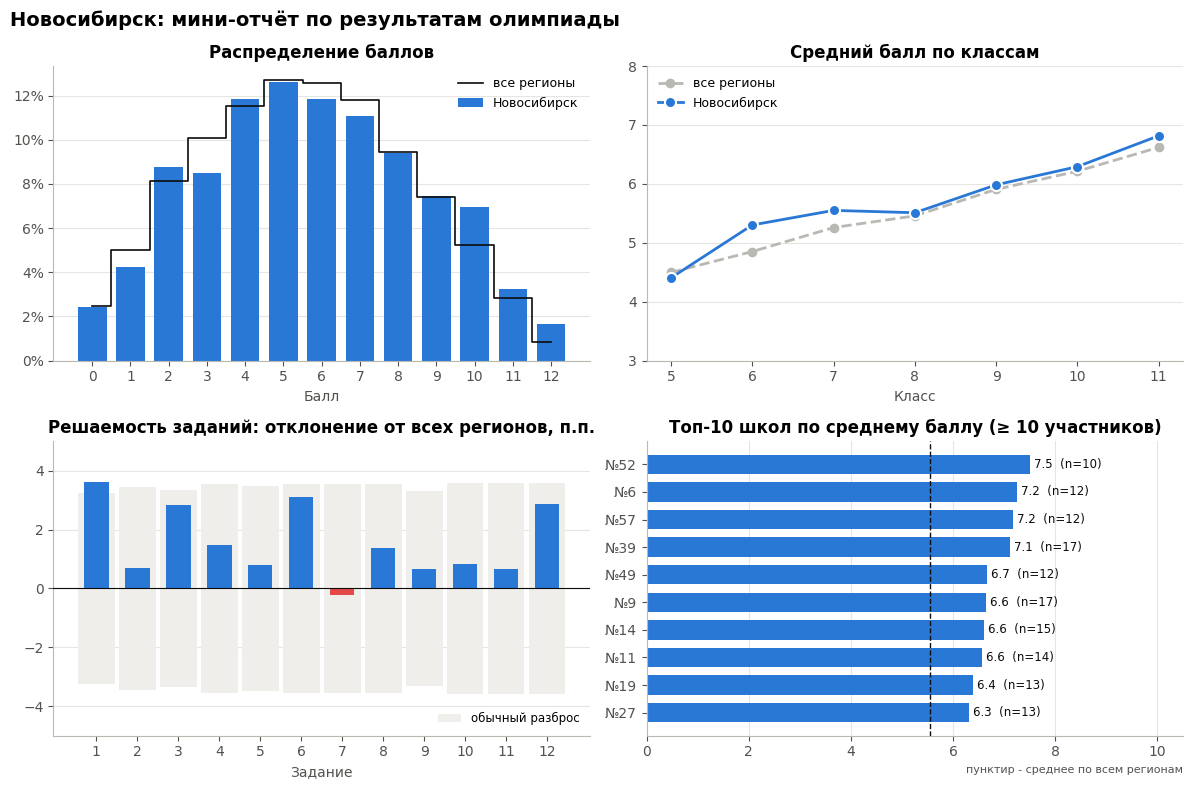

---
### Регион: Москва

- Средний балл 5.66 - 2-е место из 10 (+0.11 к среднему по всем регионам).
- Заметно выделяется задание 9: решают на 3.5 п.п. чаще, чем в других регионах.
- Относительно той же параллели по всем регионам лучше всего выступил 8 класс (+0.37 балла), слабее всего - 11 класс (-0.07).

,Значение
Участников,824
Школ,59
Средний балл,5.66 (все регионы: 5.55)
Место по среднему баллу,2 из 10
Медиана,6
Высокий результат (9+),17.4% (все: 16.3%)
Прошли все 12 заданий,58.1% (все: 61.6%)
Среднее время на задание,74 сек
Были разрывы связи,18.8%


**Топ-5 школ**

,Школа №,Участников,Средний балл,"Высокий результат, %",Сек на задание
1,26,10,7.50,30.00,73.59
2,4,14,7.36,35.71,76.08
3,43,12,6.83,25.00,73.52
4,34,19,6.79,31.58,73.14
5,28,16,6.75,25.00,76.82


**Результаты по классам**

,Участников,Средний балл,"Высокий результат, %","Прошли все 12, %",Балл по всем регионам
Класс,,,,,
5,128,4.76,10.16,54.69,4.50
6,110,4.97,12.73,56.36,4.85
7,122,5.22,13.11,64.75,5.26
8,115,5.83,13.91,56.52,5.46
9,134,6.05,20.90,55.97,5.91
10,107,6.35,25.23,57.94,6.21
11,108,6.55,26.85,61.11,6.62


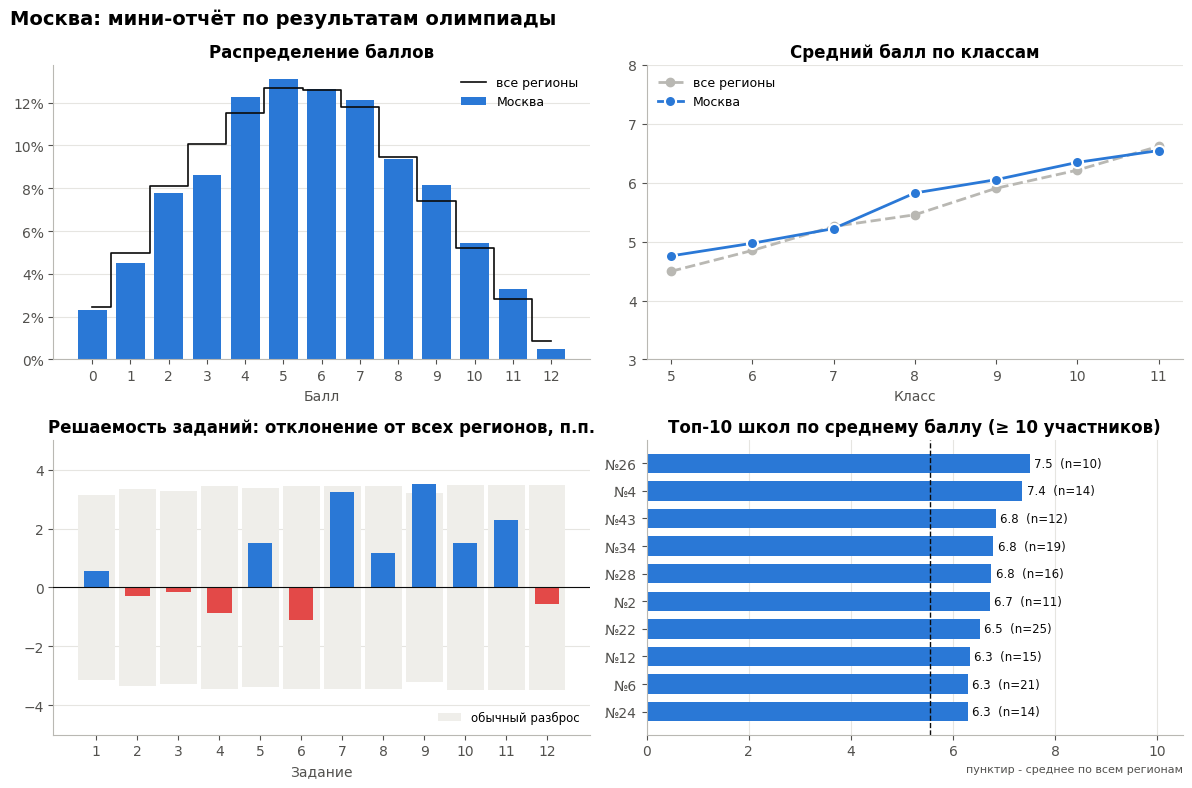

---
### Регион: Екатеринбург

- Средний балл 5.62 - 3-е место из 10 (+0.07 к среднему по всем регионам).
- Заметно выделяется задание 3: решают на 3.6 п.п. чаще, чем в других регионах.
- Относительно той же параллели по всем регионам лучше всего выступил 5 класс (+0.88 балла), слабее всего - 7 класс (-0.35).

,Значение
Участников,745
Школ,59
Средний балл,5.62 (все регионы: 5.55)
Место по среднему баллу,3 из 10
Медиана,6
Высокий результат (9+),15.7% (все: 16.3%)
Прошли все 12 заданий,62.4% (все: 61.6%)
Среднее время на задание,73 сек
Были разрывы связи,17.9%


**Топ-5 школ**

,Школа №,Участников,Средний балл,"Высокий результат, %",Сек на задание
1,22,10,7.10,20.00,74.81
2,35,11,7.09,27.27,77.67
3,47,18,6.61,27.78,73.43
4,31,16,6.56,25.00,73.38
5,26,10,6.50,30.00,72.99


**Результаты по классам**

,Участников,Средний балл,"Высокий результат, %","Прошли все 12, %",Балл по всем регионам
Класс,,,,,
5,91,5.37,17.58,71.43,4.50
6,102,4.68,6.86,64.71,4.85
7,108,4.91,11.11,62.04,5.26
8,107,5.17,7.48,56.07,5.46
9,115,6.28,21.74,53.91,5.91
10,118,5.92,18.64,63.56,6.21
11,104,6.90,25.96,67.31,6.62


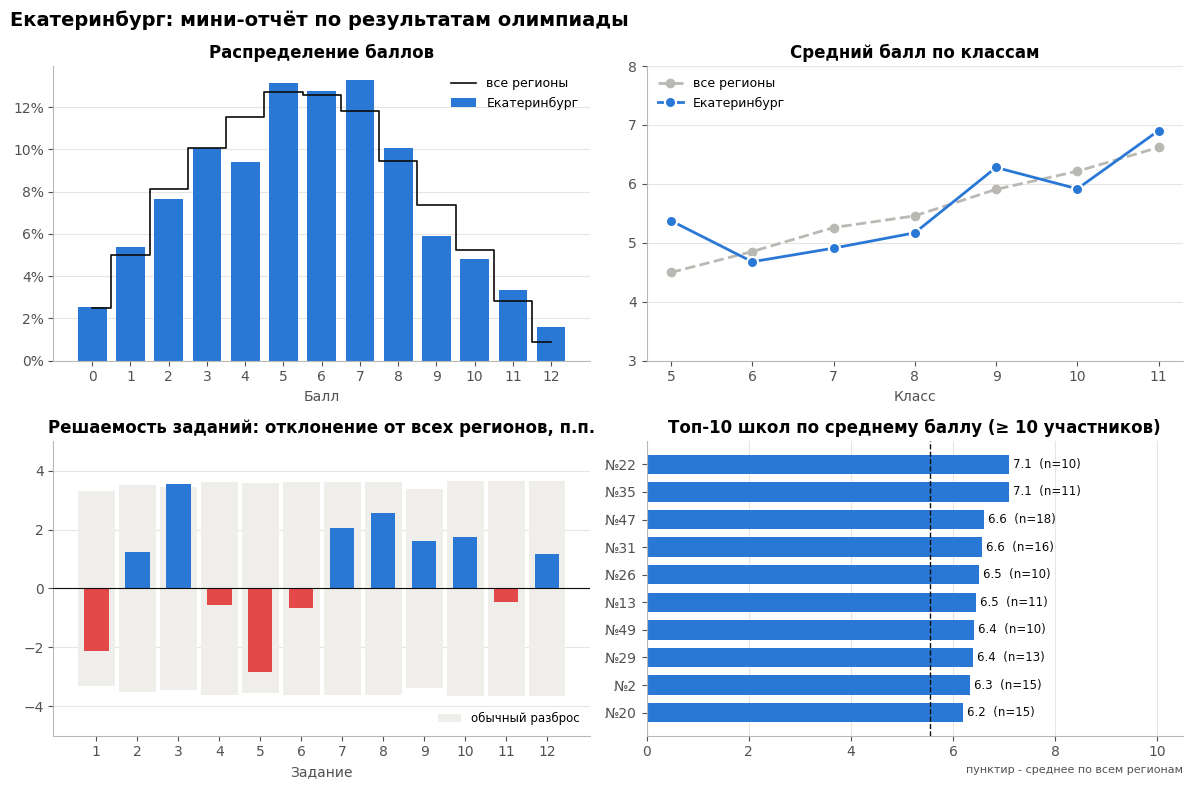

---
### Регион: Ростов-на-Дону

- Средний балл 5.60 - 4-е место из 10 (+0.05 к среднему по всем регионам).
- Задания решают примерно так же, как в других регионах: отклонения от -2.2 до +2.5 п.п.
- Относительно той же параллели по всем регионам лучше всего выступил 11 класс (+0.41 балла), слабее всего - 9 класс (-0.28).
- Школа №13 держится заметно выше остальных: средний балл 7.95 при 20 участниках. Стоит посмотреть на неё в следующих турах.

,Значение
Участников,787
Школ,59
Средний балл,5.60 (все регионы: 5.55)
Место по среднему баллу,4 из 10
Медиана,6
Высокий результат (9+),16.8% (все: 16.3%)
Прошли все 12 заданий,61.6% (все: 61.6%)
Среднее время на задание,74 сек
Были разрывы связи,18.4%


**Топ-5 школ**

,Школа №,Участников,Средний балл,"Высокий результат, %",Сек на задание
1,13,20,7.95,45.00,75.59
2,4,13,7.77,61.54,74.16
3,45,14,7.14,35.71,74.75
4,37,15,6.73,26.67,75.32
5,22,15,6.60,26.67,75.46


**Результаты по классам**

,Участников,Средний балл,"Высокий результат, %","Прошли все 12, %",Балл по всем регионам
Класс,,,,,
5,98,4.27,6.12,66.33,4.50
6,98,4.66,7.14,57.14,4.85
7,131,5.60,13.74,58.02,5.26
8,132,5.37,12.88,59.09,5.46
9,99,5.63,19.19,59.60,5.91
10,114,6.34,24.56,61.40,6.21
11,115,7.03,32.17,70.43,6.62


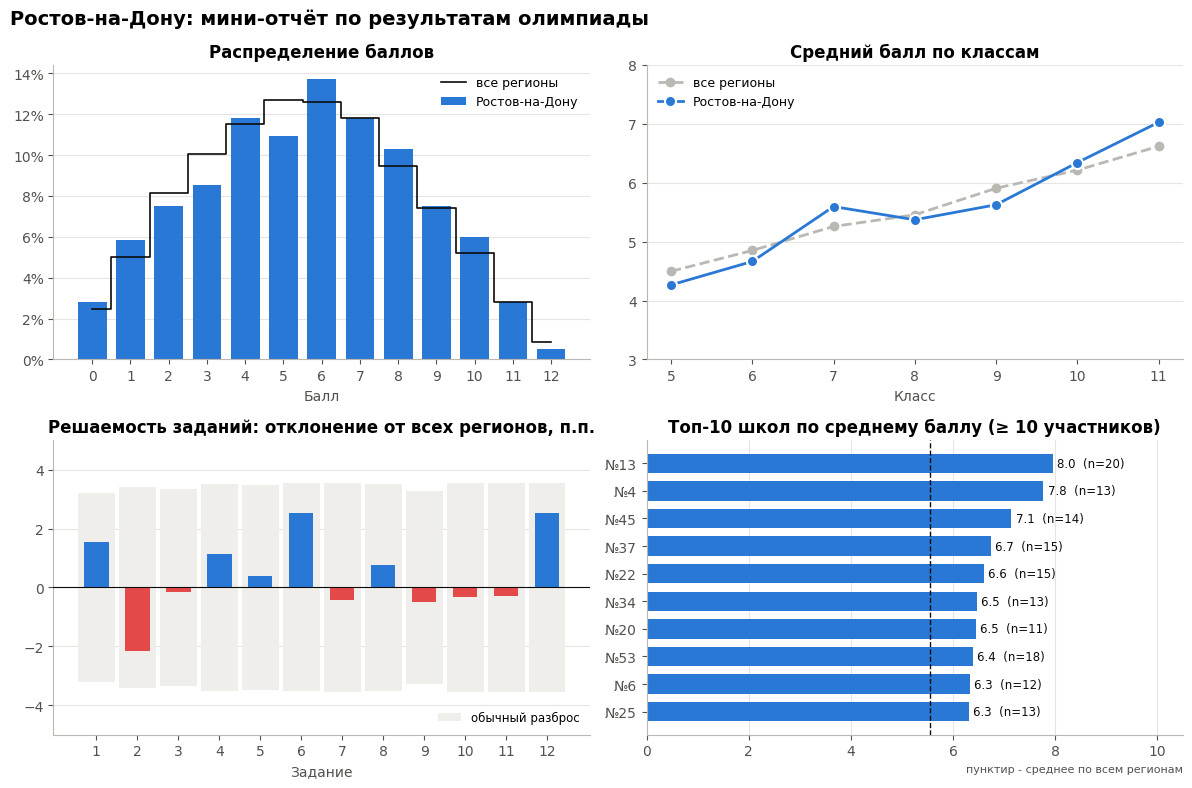

---
### Регион: Санкт-Петербург

- Средний балл 5.58 - 5-е место из 10 (+0.03 к среднему по всем регионам).
- Задания решают примерно так же, как в других регионах: отклонения от -1.8 до +2.6 п.п.
- Относительно той же параллели по всем регионам лучше всего выступил 7 класс (+0.36 балла), слабее всего - 11 класс (-0.18).

,Значение
Участников,796
Школ,59
Средний балл,5.58 (все регионы: 5.55)
Место по среднему баллу,5 из 10
Медиана,6
Высокий результат (9+),16.2% (все: 16.3%)
Прошли все 12 заданий,64.2% (все: 61.6%)
Среднее время на задание,73 сек
Были разрывы связи,18.1%


**Топ-5 школ**

,Школа №,Участников,Средний балл,"Высокий результат, %",Сек на задание
1,11,12,7.92,50.00,73.08
2,56,10,7.40,30.00,71.00
3,40,21,7.19,38.10,74.71
4,13,11,6.73,36.36,74.53
5,51,12,6.67,25.00,74.09


**Результаты по классам**

,Участников,Средний балл,"Высокий результат, %","Прошли все 12, %",Балл по всем регионам
Класс,,,,,
5,95,4.35,9.47,65.26,4.50
6,138,4.91,10.14,67.39,4.85
7,110,5.62,12.73,60.91,5.26
8,118,5.53,16.95,66.10,5.46
9,101,5.88,21.78,58.42,5.91
10,126,6.29,18.25,68.25,6.21
11,108,6.44,25.00,61.11,6.62


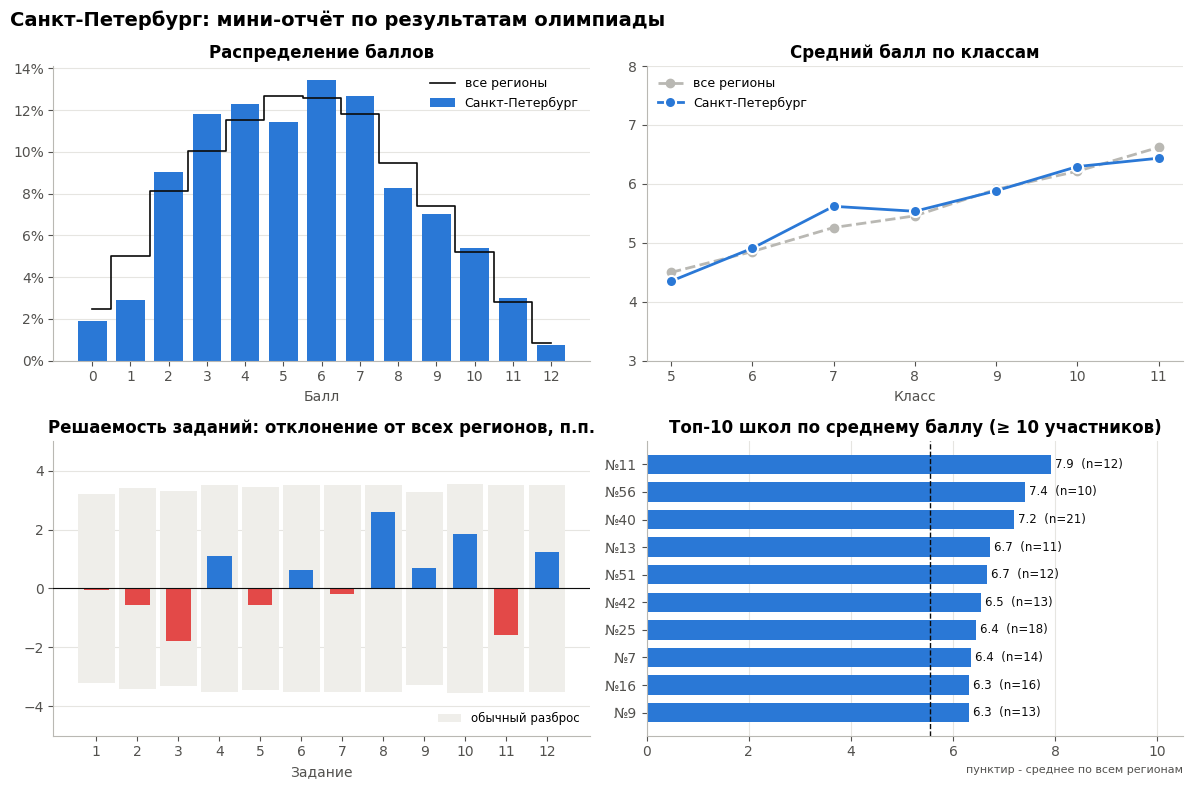

---
### Регион: Воронеж

- Средний балл 5.50 - 6-е место из 10 (−0.04 к среднему по всем регионам).
- Задания решают примерно так же, как в других регионах: отклонения от -2.1 до +1.7 п.п.
- Относительно той же параллели по всем регионам лучше всего выступил 7 класс (+0.16 балла), слабее всего - 5 класс (-0.28).

,Значение
Участников,792
Школ,59
Средний балл,5.50 (все регионы: 5.55)
Место по среднему баллу,6 из 10
Медиана,6
Высокий результат (9+),15.2% (все: 16.3%)
Прошли все 12 заданий,63.5% (все: 61.6%)
Среднее время на задание,73 сек
Были разрывы связи,17.4%


**Топ-5 школ**

,Школа №,Участников,Средний балл,"Высокий результат, %",Сек на задание
1,46,10,7.10,50.00,72.07
2,53,12,6.67,16.67,72.77
3,40,17,6.59,17.65,73.90
4,27,12,6.50,25.00,74.20
5,32,17,6.47,29.41,73.61


**Результаты по классам**

,Участников,Средний балл,"Высокий результат, %","Прошли все 12, %",Балл по всем регионам
Класс,,,,,
5,112,4.21,5.36,66.96,4.50
6,125,4.98,12.00,64.80,4.85
7,110,5.42,10.91,65.45,5.26
8,125,5.57,16.00,57.60,5.46
9,126,5.78,15.87,68.25,5.91
10,91,6.22,20.88,65.93,6.21
11,103,6.58,27.18,55.34,6.62


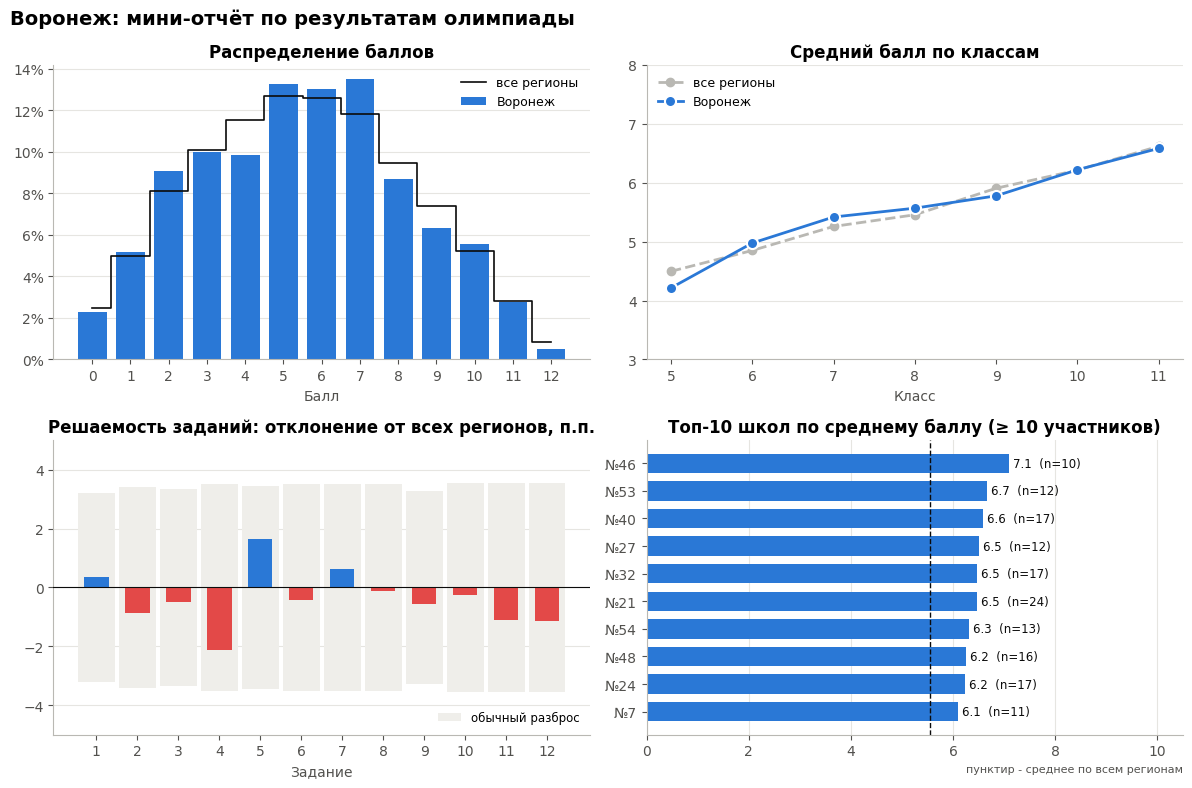

---
### Регион: Уфа

- Средний балл 5.49 - 7-е место из 10 (−0.06 к среднему по всем регионам).
- Задания решают примерно так же, как в других регионах: отклонения от -2.7 до +2.3 п.п.
- Относительно той же параллели по всем регионам лучше всего выступил 9 класс (+0.07 балла), слабее всего - 8 класс (-0.30).

,Значение
Участников,838
Школ,59
Средний балл,5.49 (все регионы: 5.55)
Место по среднему баллу,7 из 10
Медиана,5
Высокий результат (9+),15.6% (все: 16.3%)
Прошли все 12 заданий,63.0% (все: 61.6%)
Среднее время на задание,73 сек
Были разрывы связи,15.9%


**Топ-5 школ**

,Школа №,Участников,Средний балл,"Высокий результат, %",Сек на задание
1,57,11,7.00,36.36,73.71
2,52,15,6.87,26.67,72.25
3,53,16,6.56,31.25,73.33
4,32,15,6.53,13.33,73.09
5,29,12,6.50,41.67,73.64


**Результаты по классам**

,Участников,Средний балл,"Высокий результат, %","Прошли все 12, %",Балл по всем регионам
Класс,,,,,
5,125,4.55,12.00,54.40,4.50
6,121,4.62,6.61,62.81,4.85
7,128,5.27,12.50,66.41,5.26
8,100,5.16,11.00,66.00,5.46
9,112,5.97,22.32,61.61,5.91
10,124,6.24,20.97,58.87,6.21
11,128,6.56,23.44,71.09,6.62


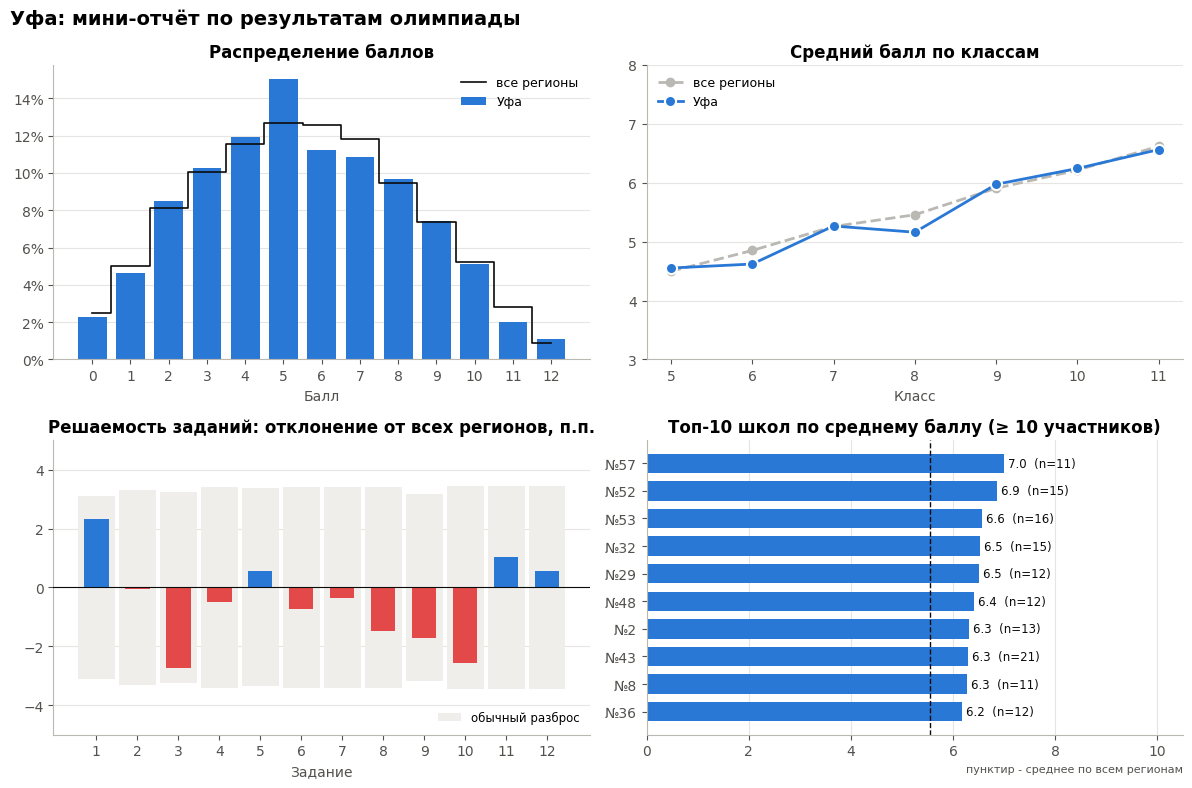

---
### Регион: Казань

- Средний балл 5.48 - 8-е место из 10 (−0.06 к среднему по всем регионам).
- Задания решают примерно так же, как в других регионах: отклонения от -2.2 до +1.8 п.п.
- Относительно той же параллели по всем регионам лучше всего выступил 10 класс (+0.21 балла), слабее всего - 5 класс (-0.23).

,Значение
Участников,811
Школ,59
Средний балл,5.48 (все регионы: 5.55)
Место по среднему баллу,8 из 10
Медиана,5
Высокий результат (9+),17.4% (все: 16.3%)
Прошли все 12 заданий,58.9% (все: 61.6%)
Среднее время на задание,74 сек
Были разрывы связи,15.5%


**Топ-5 школ**

,Школа №,Участников,Средний балл,"Высокий результат, %",Сек на задание
1,5,21,7.29,42.86,74.17
2,24,12,6.92,33.33,74.39
3,11,10,6.80,40.00,71.28
4,30,13,6.77,30.77,73.33
5,9,15,6.73,40.00,72.02


**Результаты по классам**

,Участников,Средний балл,"Высокий результат, %","Прошли все 12, %",Балл по всем регионам
Класс,,,,,
5,122,4.26,6.56,60.66,4.50
6,127,4.75,11.02,59.84,4.85
7,114,5.05,10.53,61.40,5.26
8,107,5.49,17.76,63.55,5.46
9,114,6.00,22.81,57.02,5.91
10,118,6.42,26.27,51.69,6.21
11,109,6.61,28.44,58.72,6.62


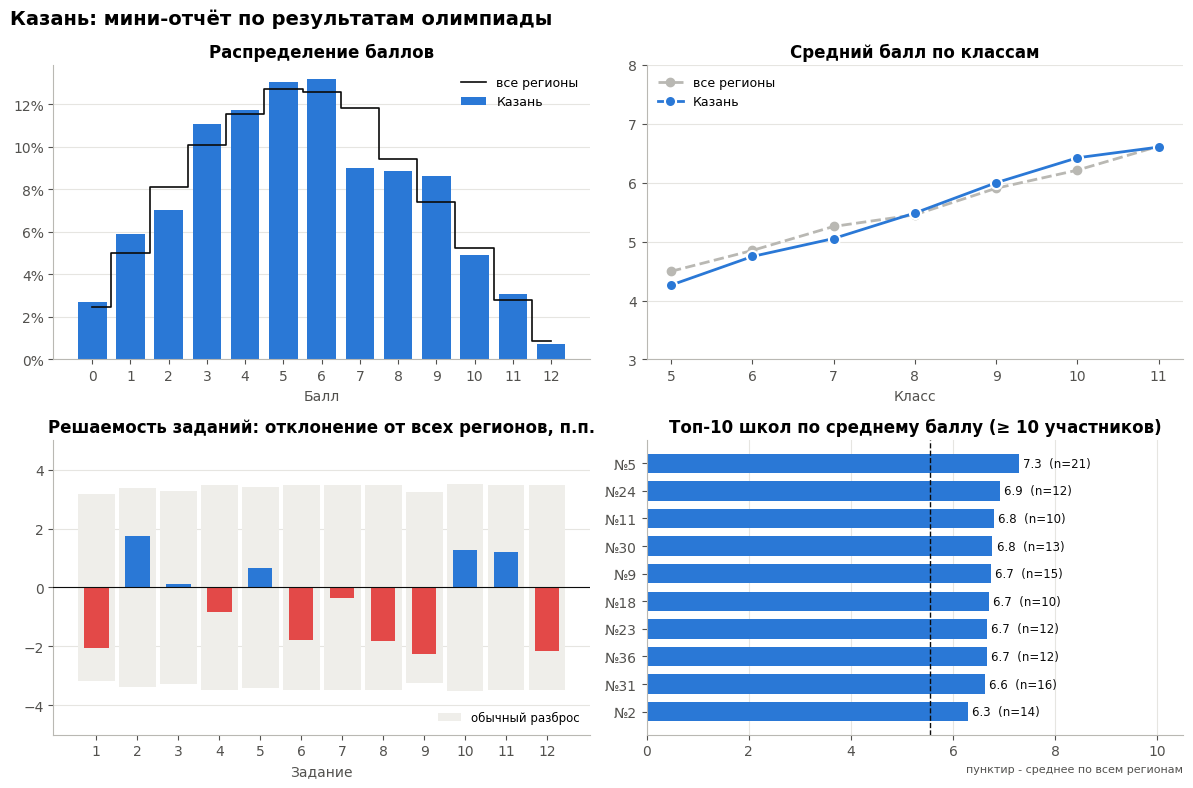

---
### Регион: Краснодар

- Средний балл 5.43 - 9-е место из 10 (−0.12 к среднему по всем регионам).
- Задания решают примерно так же, как в других регионах: отклонения от -3.5 до +1.5 п.п.
- Относительно той же параллели по всем регионам лучше всего выступил 7 класс (-0.03 балла), слабее всего - 11 класс (-0.28).

,Значение
Участников,801
Школ,59
Средний балл,5.43 (все регионы: 5.55)
Место по среднему баллу,9 из 10
Медиана,5
Высокий результат (9+),14.6% (все: 16.3%)
Прошли все 12 заданий,61.8% (все: 61.6%)
Среднее время на задание,73 сек
Были разрывы связи,17.9%


**Топ-5 школ**

,Школа №,Участников,Средний балл,"Высокий результат, %",Сек на задание
1,53,12,7.17,41.67,74.76
2,13,18,6.83,27.78,73.57
3,6,17,6.76,23.53,74.22
4,12,13,6.54,23.08,76.09
5,49,15,6.47,26.67,71.04


**Результаты по классам**

,Участников,Средний балл,"Высокий результат, %","Прошли все 12, %",Балл по всем регионам
Класс,,,,,
5,109,4.35,10.09,58.72,4.50
6,120,4.69,10.83,60.00,4.85
7,104,5.23,10.58,58.65,5.26
8,101,5.33,10.89,61.39,5.46
9,105,5.71,12.38,63.81,5.91
10,139,6.12,17.99,60.43,6.21
11,123,6.34,26.83,69.11,6.62


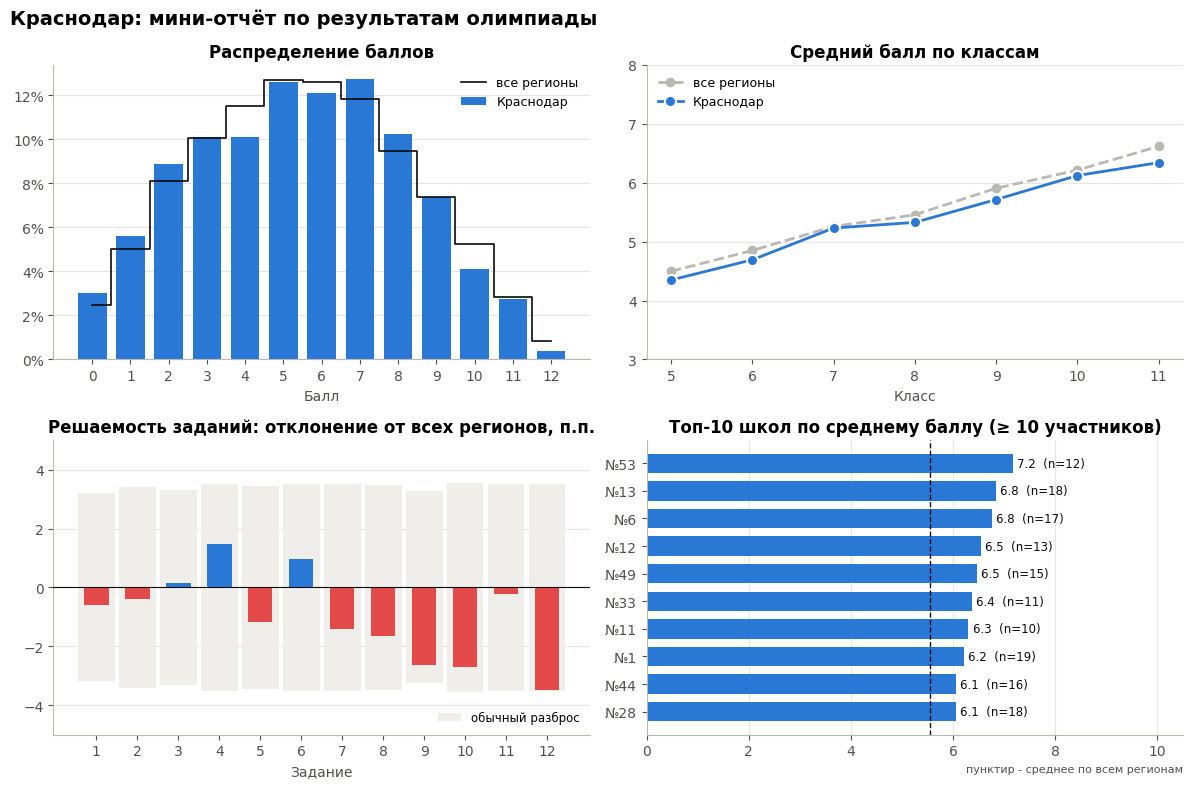

---
### Регион: Пермь

- Средний балл 5.38 - 10-е место из 10 (−0.17 к среднему по всем регионам).
- Заметно выделяется задание 1: решают на 3.9 п.п. реже, чем в других регионах.
- Относительно той же параллели по всем регионам лучше всего выступил 8 класс (+0.11 балла), слабее всего - 7 класс (-0.50).

,Значение
Участников,757
Школ,59
Средний балл,5.38 (все регионы: 5.55)
Место по среднему баллу,10 из 10
Медиана,5
Высокий результат (9+),14.7% (все: 16.3%)
Прошли все 12 заданий,60.2% (все: 61.6%)
Среднее время на задание,74 сек
Были разрывы связи,17.8%


**Топ-5 школ**

,Школа №,Участников,Средний балл,"Высокий результат, %",Сек на задание
1,48,14,7.29,21.43,74.61
2,28,11,6.91,27.27,77.26
3,37,10,6.70,30.00,72.73
4,49,12,6.67,16.67,72.90
5,34,17,6.41,23.53,72.83


**Результаты по классам**

,Участников,Средний балл,"Высокий результат, %","Прошли все 12, %",Балл по всем регионам
Класс,,,,,
5,114,4.51,9.65,58.77,4.50
6,106,4.92,7.55,65.09,4.85
7,127,4.76,9.45,56.69,5.26
8,92,5.57,17.39,66.30,5.46
9,97,5.67,17.53,57.73,5.91
10,99,5.92,20.20,60.61,6.21
11,122,6.41,22.13,58.20,6.62


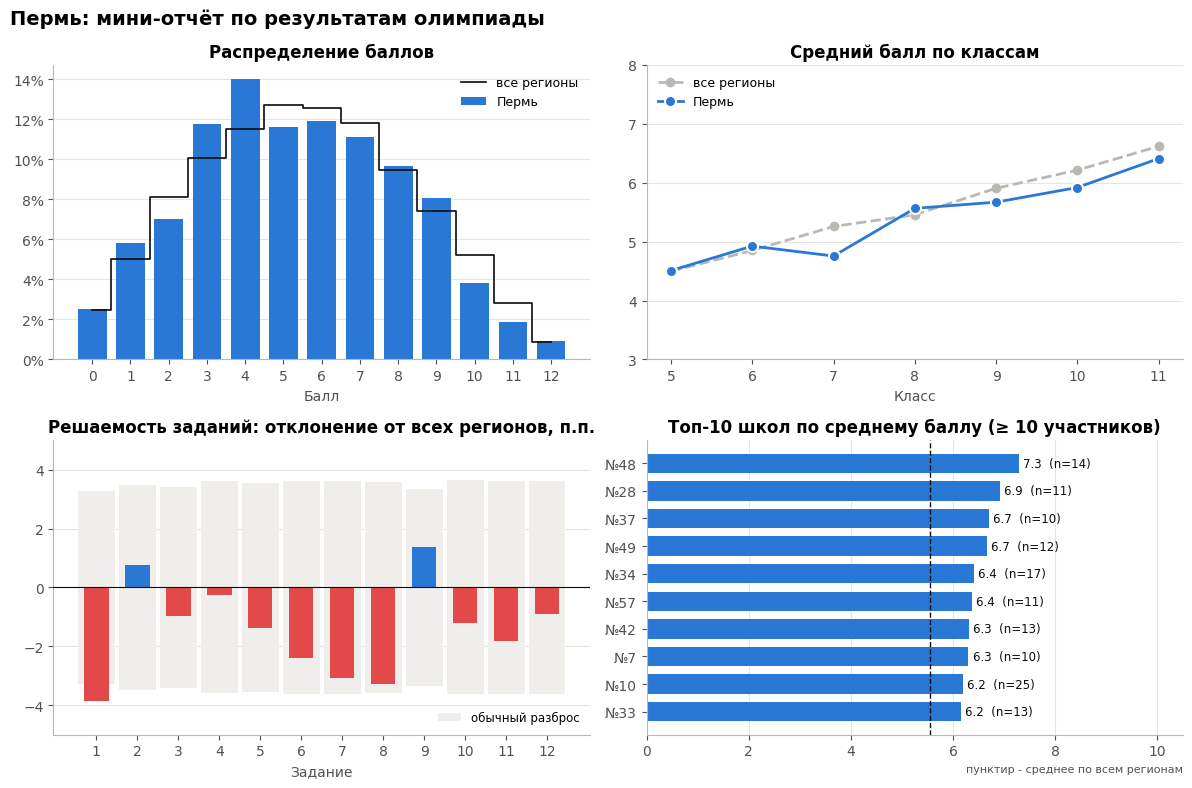

In [33]:
for region in REGION_SUMMARY.index:
    region_report(region)

<a id="8"></a>
## 8. Аномалии
Сводим все найденные аномалии: технические (удалены при очистке) и поведенческие (оставлены, но помечены).

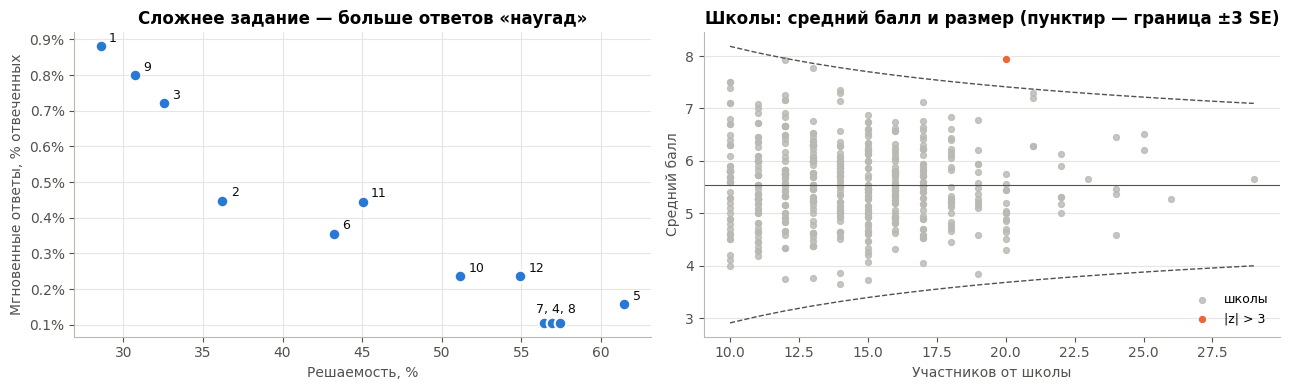

**Школы, результат которых статистически отличается от среднего (|z| > 3)**

,Регион,Школа №,Участников,Средний балл,"Высокий результат, %",Сек на задание,z-оценка
0,Ростов-на-Дону,13,20,7.95,45.00,75.59,3.86


In [34]:
instant_by_task = task_stats['Мгновенные ответы, %'].sort_index()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
ax.scatter(task_stats['Решаемость, %'], task_stats['Мгновенные ответы, %'], s=70, color=BLUE,
           edgecolor='white', linewidth=1.5, zorder=3)
cluster = [7, 4, 8]  # точки почти совпадают — подписываем группой
for t, row in task_stats.iterrows():
    if t in cluster[1:]:
        continue
    text = ', '.join(map(str, cluster)) if t == cluster[0] else str(t)
    ax.annotate(text, (row['Решаемость, %'], row['Мгновенные ответы, %']), xytext=(-6, 7) if t == cluster[0] else (6, 3),
                textcoords='offset points', fontsize=9, color=INK)
ax.set(title='Сложнее задание — больше ответов «наугад»',
       xlabel='Решаемость, %', ylabel='Мгновенные ответы, % отвеченных')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax.grid(axis='x', visible=True)

ax = axes[1]
sch = schools.query('participants >= @MIN_SCHOOL_N')
ax.scatter(sch['participants'], sch['mean_score'], s=18, color=GRAY, alpha=0.8, label='школы')
out = sch[sch['z'].abs() > 3]
ax.scatter(out['participants'], out['mean_score'], s=40, color=ORANGE, edgecolor='white', zorder=3,
           label='|z| > 3')
n_grid = np.arange(MIN_SCHOOL_N, sch['participants'].max() + 1)
for sign in (1, -1):
    ax.plot(n_grid, overall_mean + sign * 3 * score_sd / np.sqrt(n_grid), color=MUTED, ls='--', lw=1)
ax.axhline(overall_mean, color=MUTED, lw=0.8)
ax.set(title='Школы: средний балл и размер (пунктир — граница ±3 SE)', xlabel='Участников от школы',
       ylabel='Средний балл')
ax.legend(loc='lower right', fontsize=9)
fig.tight_layout()
plt.show()

display(Markdown('**Школы, результат которых статистически отличается от среднего (|z| > 3)**'))
display(out.sort_values('z', ascending=False).rename(columns=SCHOOL_COLS).reset_index(drop=True).round(2))

In [35]:
tech = df.groupby('disconnects').agg(participants=('student_id', 'size'), mean_score=('total_score', 'mean'),
                                     completion=('completed_all', 'mean'))
tech['completion'] *= 100
display(Markdown('**Разрывы связи и результат**'))
display(tech.rename(columns={'participants': 'Участников', 'mean_score': 'Средний балл',
                             'completion': 'Прошли все 12, %'}))

hour = df.groupby('start_hour').agg(participants=('student_id', 'size'), mean_score=('total_score', 'mean'))
display(Markdown('**Час старта сессии**'))
display(hour.rename(columns={'participants': 'Участников', 'mean_score': 'Средний балл'}))

**Разрывы связи и результат**

,Участников,Средний балл,"Прошли все 12, %"
disconnects,,,
0,6542,5.53,61.82
1,1253,5.58,61.53
2,122,5.96,50.82
3,10,5.70,30.00
4,1,5.00,0.00


**Час старта сессии**

,Участников,Средний балл
start_hour,,
9,2615,5.64
10,2622,5.49
11,2691,5.51


**Сводка по аномалиям**

| Аномалия | Масштаб | Что сделали | Вывод |
|---|---|---|---|
| Полные дубликаты строк | 37 | удалены | нужна дедупликация на стороне выгрузки (уникальный ключ `student_id`) |
| Сверхбыстрые сессии (~20 сек) | 72 (0,9%) | удалены | доля верных = случайное угадывание, это тестовые или бот-прохождения. Нужен фильтр на платформе |
| Опечатки в регионе | 259 строк | нормализованы | регион вводится вручную, лучше заменить поле на выпадающий список |
| «Мгновенные» ответы (5 сек) | ~4% участников | помечены | сосредоточены на самых сложных заданиях: это угадывание, а не сбой |
| Школы с экстремальными результатами | 1 школа с \|z\| > 3 (Ростов-на-Дону, №13) | помечена | для 590 школ такое число ожидается случайно; следить на следующих турах |
| Разрывы связи | 17% участников | оставлены | на балл и завершение не влияют, платформа корректно восстанавливает сессию |

<a id="9"></a>
## 9. Проверка статистических гипотез
Баллы - целые числа от 0 до 12, поэтому берём ранговые тесты: Краскела–Уоллиса для нескольких групп и Манна–Уитни для двух. Рядом с p-value приводим ε² - насколько сильно признак влияет на результат (меньше 0,01 означает «практически не влияет»). Тестов семь, поэтому порог значимости ужесточаем поправкой Бонферрони: 0,05 / 7 = 0,007.

**Про городские и сельские школы.** В данных нет типа населённого пункта - все 10 регионов крупные города, поэтому проверить эту гипотезу нельзя. Вместо неё проверяем часовые пояса.

In [36]:
def kruskal_test(col, data=df):
    groups = [g['total_score'].to_numpy() for _, g in data.groupby(col)]
    res = stats.kruskal(*groups)
    return res.statistic, res.pvalue, res.statistic / (len(data) - 1)

hypotheses = [
    ('Регион', 'region'),
    ('Часовой пояс (МСК/МСК+2/МСК+4)', 'tz_group'),
    ('Класс', 'grade'),
    ('Тип устройства', 'device_type'),
    ('Были ли разрывы связи', 'had_disconnect'),
    ('Число попыток входа (1 или 2)', 'attempts_count'),
    ('Час старта (9/10/11)', 'start_hour'),
]
alpha_bonf = 0.05 / len(hypotheses)
rows = []
for name, col in hypotheses:
    h, p, eps2 = kruskal_test(col)
    means = df.groupby(col)['total_score'].mean()
    rows.append({'Средний балл различается по признаку': name, 'H': h, 'p-value': p, 'ε²': eps2,
                 'Разброс средних': f'{means.min():.2f} - {means.max():.2f}',
                 f'Значимо (α={alpha_bonf:.3f})': 'да' if p < alpha_bonf else 'нет'})
hyp = pd.DataFrame(rows)
display(hyp.style.format('{:.1f}', subset=['H']).format('{:.3g}', subset=['p-value'])
        .format('{:.4f}', subset=['ε²']))

,Средний балл различается по признаку,H,p-value,ε²,Разброс средних,Значимо (α=0.007)
0,Регион,9.8,0.366,0.0012,5.38 - 5.73,нет
1,Часовой пояс (МСК/МСК+2/МСК+4),3.7,0.16,0.0005,5.49 - 5.73,нет
2,Класс,480.3,1.5e-100,0.0606,4.50 - 6.62,да
3,Тип устройства,0.3,0.841,0.0000,5.53 - 5.60,нет
4,Были ли разрывы связи,0.8,0.362,0.0001,5.53 - 5.61,нет
5,Число попыток входа (1 или 2),0.7,0.413,0.0001,5.52 - 5.58,нет
6,Час старта (9/10/11),3.4,0.179,0.0004,5.49 - 5.64,нет


In [37]:
msk = df.loc[df['tz_group'] == 'МСК', 'total_score']
nsk = df.loc[df['tz_group'] == 'МСК+4', 'total_score']
mw = stats.mannwhitneyu(msk, nsk)
print(f'Манн–Уитни, МСК vs МСК+4 (Новосибирск): средние {msk.mean():.2f} vs {nsk.mean():.2f}, p-value = {mw.pvalue:.3f}')

top_reg, low_reg = REGION_SUMMARY.index[0], REGION_SUMMARY.index[-1]
mw2 = stats.mannwhitneyu(df.loc[df['region'] == top_reg, 'total_score'], df.loc[df['region'] == low_reg, 'total_score'])
print(f'Манн–Уитни, лучший vs худший регион ({top_reg} vs {low_reg}): p-value = {mw2.pvalue:.3f} '
      f'(без поправки на множественные сравнения 45 пар)')

Манн–Уитни, МСК vs МСК+4 (Новосибирск): средние 5.54 vs 5.73, p-value = 0.126
Манн–Уитни, лучший vs худший регион (Новосибирск vs Пермь): p-value = 0.019 (без поправки на множественные сравнения 45 пар)


**Результаты проверки гипотез**
* **Класс - единственный фактор, который реально влияет на результат.** Средний балл растёт с 4,50 в 5 классе до 6,62 в 11-м, и это не случайное колебание (p < 0,001). При этом связь умеренная: класс объясняет около 6% различий между участниками, остальное - индивидуальная подготовка. Сильный пятиклассник спокойно обгоняет среднего одиннадцатиклассника.
* **Регионы не различаются** (p = 0,37). Разрыв между первым и последним местом - 0,35 балла, в пределах случайных колебаний. Прямое сравнение Новосибирска и Перми даёт p = 0,019, но эта пара выбрана задним числом как крайняя из 45 возможных: при таком переборе «значимая» пара находится почти всегда. Рейтинг регионов можно публиковать только с этой оговоркой.
* **Часовой пояс не влияет** (p = 0,16). Если время в выгрузке московское, Новосибирск решал в 13-16 часов по местному - на результате это не сказалось.
* Устройство, разрывы связи, число попыток входа и час старта на балл не влияют: все p > 0,05, разброс средних между группами не превышает 0,1 балла.

<a id="10"></a>
## 10. Автоматические PDF-отчёты по регионам
`export_region_pdf(region)` собирает двухстраничный PDF (A4, альбомная ориентация) на основе `region_report`:
1. KPI-карточки, автоматические выводы, топ-5 школ и таблица по классам;
2. четыре графика мини-отчёта.

Отчёты сохраняются в папку `reports/`.

In [38]:
REGION_SLUG = {'Москва': 'moscow', 'Санкт-Петербург': 'saint_petersburg', 'Воронеж': 'voronezh',
               'Краснодар': 'krasnodar', 'Ростов-на-Дону': 'rostov_on_don', 'Казань': 'kazan',
               'Екатеринбург': 'yekaterinburg', 'Пермь': 'perm', 'Уфа': 'ufa', 'Новосибирск': 'novosibirsk'}

def _draw_table(ax, table, title, col_widths=None):
    ax.axis('off')
    ax.set_title(title, loc='left', fontsize=11, fontweight='bold', color=INK)
    t = ax.table(cellText=table.to_numpy(), colLabels=list(table.columns), loc='upper left',
                 cellLoc='center', colLoc='center', colWidths=col_widths)
    t.auto_set_font_size(False)
    t.set_fontsize(8.5)
    t.scale(1, 1.35)
    for (row, _), cell in t.get_celld().items():
        cell.set_edgecolor('#e6e5e1')
        if row == 0:
            cell.set_height(cell.get_height() * 1.9)
            cell.set_facecolor('#eef4fc')
            cell.set_text_props(fontweight='bold', color=INK)

def export_region_pdf(region, out_dir=REPORT_DIR):
    rep = region_report(region, show=False)
    s = REGION_SUMMARY.loc[region]
    path = Path(out_dir) / f'report_{REGION_SLUG.get(region, region)}.pdf'

    with PdfPages(path) as pdf:
        page = plt.figure(figsize=(11.69, 8.27))
        page.text(0.04, 0.95, 'олимпиада для школьников · 10.04.2026 · мини-отчёт по региону',
                  fontsize=10, color=MUTED)
        page.text(0.04, 0.895, region, fontsize=24, fontweight='bold', color=INK)

        tiles = [('Участников', f"{int(s['participants'])}", f"{int(s['schools'])} школ"),
                 ('Средний балл', f"{s['mean_score']:.2f}", f"все регионы: {overall_mean:.2f}"),
                 ('Место', f"{int(s['rank'])} / {len(REGION_SUMMARY)}", 'по среднему баллу'),
                 ('Высокий результат', f"{s['high_share']:.1f}%", '9+ баллов из 12'),
                 ('Прошли все задания', f"{s['completion']:.0f}%", f"{s['avg_time']:.0f} сек на задание")]
        for i, (label, value, sub) in enumerate(tiles):
            x = 0.04 + i * 0.187
            page.patches.append(plt.Rectangle((x, 0.725), 0.172, 0.13, transform=page.transFigure,
                                              facecolor='#f4f7fb', edgecolor='none'))
            page.text(x + 0.012, 0.825, label, fontsize=9, color=MUTED)
            page.text(x + 0.012, 0.77, value, fontsize=20, fontweight='bold', color=BLUE)
            page.text(x + 0.012, 0.74, sub, fontsize=8.5, color=MUTED)

        page.text(0.04, 0.68, 'Ключевые выводы', fontsize=11, fontweight='bold', color=INK)
        y = 0.645
        for line in rep['insights']:
            wrapped = fill(line, 140)
            page.text(0.05, y, '•  ' + wrapped.replace('\n', '\n    '), fontsize=9.5, color=INK, va='top',
                      linespacing=1.4)
            y -= 0.024 * (wrapped.count('\n') + 1) + 0.014

        top = rep['top_schools'].drop(columns='z-оценка', errors='ignore').copy()
        top.insert(0, 'Место', top.index)
        top['Средний балл'] = top['Средний балл'].map('{:.2f}'.format)
        top['Высокий результат, %'] = top['Высокий результат, %'].map('{:.0f}'.format)
        top['Сек на задание'] = top['Сек на задание'].map('{:.0f}'.format)
        top.columns = ['Место', 'Школа №', 'Участ-\nников', 'Средний\nбалл', '9+ баллов,\n%',
                       'Сек на\nзадание']
        ax1 = page.add_axes([0.04, 0.06, 0.44, 0.38])
        _draw_table(ax1, top, f'Топ-{len(top)} школ (≥ {MIN_SCHOOL_N} участников)')

        g = rep['by_grade'].reset_index()
        g['Средний балл'] = g['Средний балл'].map('{:.2f}'.format)
        g['Балл по всем регионам'] = g['Балл по всем регионам'].map('{:.2f}'.format)
        g['Высокий результат, %'] = g['Высокий результат, %'].map('{:.0f}'.format)
        g['Прошли все 12, %'] = g['Прошли все 12, %'].map('{:.0f}'.format)
        g.columns = ['Класс', 'Участ-\nников', 'Средний\nбалл', '9+ баллов,\n%', 'Прошли\nвсе 12, %',
                     'Все регионы,\nбалл']
        ax2 = page.add_axes([0.52, 0.06, 0.44, 0.38])
        _draw_table(ax2, g, 'Результаты по классам')

        page.text(0.04, 0.025, 'Различия между регионами и школами по одному туру невелики: места в рейтингах '
                  'стоит считать предварительными.', fontsize=8.5, color=MUTED)
        pdf.savefig(page)
        plt.close(page)

        rep['figure'].set_size_inches(11.69, 8.27)
        rep['figure'].tight_layout()
        pdf.savefig(rep['figure'])
        plt.close(rep['figure'])
    return path

pdf_paths = [export_region_pdf(region) for region in REGION_SUMMARY.index]
for p in pdf_paths:
    print(p, f'{p.stat().st_size / 1024:.0f} КБ')

reports\report_novosibirsk.pdf 60 КБ
reports\report_moscow.pdf 59 КБ
reports\report_yekaterinburg.pdf 60 КБ
reports\report_rostov_on_don.pdf 62 КБ
reports\report_saint_petersburg.pdf 59 КБ
reports\report_voronezh.pdf 59 КБ
reports\report_ufa.pdf 61 КБ
reports\report_kazan.pdf 59 КБ
reports\report_krasnodar.pdf 60 КБ
reports\report_perm.pdf 60 КБ


<a id="11"></a>
## 11. Итоговые выводы и рекомендации

### Качество данных
* Из 8 037 строк в анализ вошли **7 928 записей**: удалены 37 дубликатов и 72 тестовые сессии
  (~20 сек на 12 заданий, точность на уровне угадывания). Исправлено 9 вариантов написания регионов (259 строк).
* Пропуски в заданиях - это пропущенные учеником задания, а не потеря данных. Они засчитаны как 0 баллов и помечены флагами.

### Сложность заданий
* **Самые сложные - задания 1, 9 и 3** (решаемость 29-33%), **самые лёгкие - 5, 8 и 4** (57-61%).
* **На сложные задания тратят меньше времени** (64-66 сек против 79-81 сек на лёгких), и на них в 5-8 раз больше ответов
  «наугад» за 5 секунд. Похоже, трудную задачу не пытаются решить, а сдаются. Проблема, вероятно, в формулировке
  или пороге входа, а не в нехватке времени.
* Порядок сложности одинаков для всех классов. В 5 классе задания 1 и 9 решаются около уровня угадывания (22-23%).

### Аудитория и вовлечённость
* Аудитория сбалансирована: ~10% на регион, ~14% на параллель, 590 школ.
* **Вовлечённость одинаково высокая во всех классах** (60-64% проходят все 12 заданий, ~0,5 пропуска на ученика).
* **Результат определяется классом:** от 4,5 балла в 5 классе до 6,6 в 11 классе; доля высоких результатов в 11 классе в ~3 раза выше, чем в 5.

### Регионы и школы
* **Регионы статистически не различаются**: разброс средних 5,38-5,73, доверительные интервалы перекрываются.
  Регионы нельзя разделить на «сильные/слабые».
* **Школы тоже не различаются сильнее случайного.** При ~13 участниках от школы средний балл
  колеблется от 3 до 8 просто из-за маленькой выборки.
* Часовой пояс, устройство, разрывы связи и время старта на результат не влияют.

### Рекомендации для бизнеса
1. **Разделить олимпиаду по возрастным трекам** (5-6, 7-9, 10-11 классы) или адаптировать сложность. Сейчас младшие
   классы так же вовлечены, но получают заметно более низкие баллы. Это риск разочарования и оттока самой перспективной аудитории.
2. **Пересмотреть задания 1, 9 и 3:** проверить формулировки и добавить подсказку или разбор после олимпиады.
   Ранний «отвал» на задании 1 особенно опасен, потому что это первое впечатление от олимпиады.
3. **Не делать выводов о «сильных» и «слабых» регионах и школах по одному туру.** Различия между ними
   в пределах случайности. Для честного рейтинга регионов и школ нужно больше участников от школы (≥ 30) или результаты нескольких туров.
4. Для **подготовительных курсов** есть два рабочих признака: класс участника и задания, которые он не решил. Также необходим разбор сложных тем.
5. **Мобильный опыт уже на уровне пк.** Можно смело продвигать участие с телефона: результаты те же.
6. **Качество данных:** регион выбирать из списка, а не вводить вручную; отсекать сессии быстрее 1-2 минут
   на стороне платформы; дедуплицировать выгрузку по `student_id`.

### *Для дашборда

In [39]:
PBI_DIR = Path('power_bi')
PBI_DIR.mkdir(exist_ok=True)
keys = ['region', 'grade']

# для срезов
pd.DataFrame({'region': sorted(df['region'].unique())}).to_csv(
    PBI_DIR / 'dim_region.csv', index=False, encoding='utf-8-sig')
pd.DataFrame({'grade': sorted(df['grade'].unique())}).assign(
    grade_label=lambda d: d['grade'].astype(str) + ' класс').to_csv(
    PBI_DIR / 'dim_grade.csv', index=False, encoding='utf-8-sig')

# суммы для расчетов
summary = df.groupby(keys).agg(
    participants=('student_id', 'size'),
    schools=('school_number', 'nunique'),
    score_sum=('total_score', 'sum'),
    high_count=('is_high', 'sum'),
    completed_count=('completed_all', 'sum'),
    skipped_sum=('n_skipped', 'sum'),
    time_sum=('avg_time_per_task', 'sum'),
).reset_index()
summary['time_sum'] = summary['time_sum'].round().astype(int)
summary.to_csv(PBI_DIR / 'f_summary.csv', index=False, encoding='utf-8-sig')

# сколько решили и сколько приступили
solved = df.groupby(keys)[COR].sum().stack().reset_index()
attempted = df.groupby(keys)[ANS].count().stack().reset_index()
solved.columns = keys + ['col', 'solved']
attempted.columns = keys + ['col', 'attempted']
for frame in (solved, attempted):
    frame['task'] = frame['col'].str.extract(r'(\d+)').astype(int)
tasks = (solved.drop(columns='col').merge(attempted.drop(columns='col'), on=keys + ['task'])
         .merge(summary[keys + ['participants']], on=keys)
         .sort_values(keys + ['task'])[keys + ['task', 'solved', 'attempted', 'participants']])
tasks.to_csv(PBI_DIR / 'f_tasks.csv', index=False, encoding='utf-8-sig')

# распределение баллов
(df.groupby(keys + ['total_score']).size().reset_index(name='participants')
   .rename(columns={'total_score': 'score'})
   .to_csv(PBI_DIR / 'f_scores.csv', index=False, encoding='utf-8-sig'))
